In [19]:
import sys
import os
import glob
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from typing import List, Dict, Any, Optional, Tuple
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pathlib

# Add project root to path
PROJECT_ROOT = "/mnt/c/Users/obbee/research/notebooks/ML"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    os.environ["PYTHONPATH"] = PROJECT_ROOT + os.pathsep + os.environ.get("PYTHONPATH", "")

from graph_data.utils import GraphGroupDataset, GraphRecord, NUM_GROUP_CLASSES, BIT_TO_CLASS
from graph_data.models import OrthogonalEndpointRegressor, GroupClassifier
from graph_data.plotting import plot_endpoint_error_distributions, plot_pull_distributions, plot_event_display

In [18]:
import importlib
import graph_data.plotting
importlib.reload(graph_data.utils)
importlib.reload(graph_data.plotting)
importlib.reload(graph_data.models)


<module 'graph_data.models' from '/mnt/c/Users/obbee/research/notebooks/ML/graph_data/models.py'>

In [2]:
DATA_DIR = os.path.join(str(PROJECT_ROOT), "npy_data")
CLASSIFIER_WEIGHTS_PATH = os.path.join(str(PROJECT_ROOT), "model_weights", "group_classifier_12_15_2025.pth")
PROCESSED_DATA_PATH = os.path.join(DATA_DIR, "endpoint_training_data_processed.pt")

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64
LIMIT_GROUPS = 10000 # Set to None for full training
NUM_WORKERS = 0

In [4]:
def _labels_from_mask(mask: int) -> List[int]:
    """Decode a bitmask into class indices, collapsing e± into the MIP label."""
    labels = set()
    for bit, class_idx in BIT_TO_CLASS.items():
        if mask & bit:
            labels.add(class_idx)
    return list(labels)


def _count_labels(mask_values: np.ndarray) -> np.ndarray:
    """Count per-class hit occurrences for a group's bitmasks."""
    counts = np.zeros(NUM_GROUP_CLASSES, dtype=int)
    for mask in mask_values.astype(int):
        if mask <= 0:
            continue
        for class_idx in _labels_from_mask(mask):
            counts[class_idx] += 1
    return counts

    mean_error = error_per_sample.mean()

    return loss, mean_error, error_per_sample

In [5]:
def compute_endpoint_loss(output, target, weights=None, 
                                     loss_scale_span=0.1, loss_scale_dir=0.5, 
                                     quantiles=[0.16, 0.50, 0.84],
                                     error_scale=1.0): # Added for annealing
    """
    Computes a robust endpoint loss using Asymmetric Attenuation.
    
    Mechanism:
    - Calculates Left Scale (Median - q_0.16) and Right Scale (q_0.84 - Median).
    - Attenuates the left quantile loss with Left Scale.
    - Attenuates the right quantile loss with Right Scale.
    - Attenuates the median loss with Total Scale (IQR).
    
    Args:
        output: [batch, 2, 3, 3] -> (Start/Stop, XYZ, Quantiles). Index 1 must be Median.
        target: [batch, 2, 3] -> (Start/Stop, XYZ). Assumed Time-Sorted.
        weights: [batch, 2] -> Priority weights.
        error_scale: Scalar factor to multiply geometric error (for annealing).
    """
    
    # --- 1. PREPARE DATA ---
    pred_median = output[:, :, :, 1]  # [batch, 2, 3]

    # --- 2. PERMUTATION INVARIANCE ---
    loss_direct = F.smooth_l1_loss(pred_median, target, reduction='none').sum(dim=(1,2))
    target_swapped = target[:, [1, 0], :]
    loss_swapped = F.smooth_l1_loss(pred_median, target_swapped, reduction='none').sum(dim=(1,2))

    swap_mask = loss_swapped < loss_direct
    
    target_aligned = torch.where(swap_mask.view(-1, 1, 1), target_swapped, target)
    
    if weights is not None:
        weights_swapped = weights[:, [1, 0]]
        batch_weights = torch.where(swap_mask.view(-1, 1), weights_swapped, weights)
    else:
        batch_weights = torch.ones(target.shape[0], 2, device=target.device)

    # --- 3. ASYMMETRIC ATTENUATED PINBALL LOSS ---
    target_exp = target_aligned.unsqueeze(-1)
    
    # A. Calculate Asymmetric Widths from Predictions
    # Note: We enforce positivity with abs() and epsilon
    
    # Width of lower tail: |Median - q_0.16|
    sigma_left = (output[..., 1] - output[..., 0]).abs() + 1e-6
    
    # Width of upper tail: |q_0.84 - Median|
    sigma_right = (output[..., 2] - output[..., 1]).abs() + 1e-6
    
    # Total Width (IQR): Sigma_Left + Sigma_Right
    sigma_total = sigma_left + sigma_right
    
    # B. Map Widths to Quantiles
    # Index 0 (0.16) -> uses sigma_left
    # Index 1 (0.50) -> uses sigma_total (Median protected by full width)
    # Index 2 (0.84) -> uses sigma_right
    scales = torch.stack([sigma_left, sigma_total, sigma_right], dim=-1) # [batch, 2, 3, 3]
    log_scales = torch.log(scales)

    pos_loss = 0.0
    for i, q in enumerate(quantiles):
        error = target_exp - output[..., i:i+1]
        pinball = torch.max(q * error, (q - 1.0) * error)
        
        # Select the specific scale for this quantile
        scale_q = scales[..., i:i+1]
        log_scale_q = log_scales[..., i:i+1]
        
        # Attenuation: (ScaleFactor * Error / Sigma) + log(Sigma)
        attenuated_loss = (2.0 * error_scale * pinball / scale_q) + log_scale_q
        
        # Apply Importance Weights
        w = batch_weights.unsqueeze(-1).unsqueeze(-1)
        pos_loss += (attenuated_loss * w).mean()

    # --- 4. GEOMETRIC LOSSES ---
    pred_vec = pred_median[:, 1] - pred_median[:, 0]
    target_vec = target[:, 1] - target[:, 0]
    
    span_loss = F.mse_loss(pred_vec.norm(dim=1), target_vec.norm(dim=1))
    
    target_vec_aligned = target_aligned[:, 1] - target_aligned[:, 0]
    dir_loss_raw = 1.0 - F.cosine_similarity(pred_vec, target_vec_aligned, dim=1)
    
    if isinstance(loss_scale_dir, torch.Tensor):
        dir_loss = (dir_loss_raw * loss_scale_dir).mean()
    else:
        dir_loss = dir_loss_raw.mean() * loss_scale_dir

    # --- 5. METRICS ---
    loss = pos_loss + (loss_scale_span * span_loss) + dir_loss

    d_raw = (pred_median - target_aligned).norm(dim=2)
    d_start = torch.where(swap_mask, d_raw[:, 1], d_raw[:, 0])
    d_end = torch.where(swap_mask, d_raw[:, 0], d_raw[:, 1])
    d_align = torch.stack([d_start, d_end], dim=1)
    mean_error = d_align.mean()
    
    # Metric: Average Total Width (IQR)
    mean_width = sigma_total.mean()

    breakdown = {
        "PosLoss": pos_loss.item(),
        "SpanLoss": span_loss.item(),
        "DirLoss": dir_loss.item(),
        "MeanWidth": mean_width.item()
    }
    
    return loss, mean_error, d_align, breakdown

In [6]:
def inject_classifier_probabilities(dataset: GraphGroupDataset, classifier: nn.Module, device: str):
    """
    Runs the classifier on the dataset and injects 'group_probs' into each GraphRecord.
    Modifies dataset in-place.
    """
    print("\nRunning Classifier Inference to generate probabilities...")
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    classifier.eval()
    
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Classifying Groups"):
            batch = batch.to(device)
            # Classifier returns logits, apply sigmoid for probabilities
            logits = classifier(batch) # Shape [B, 3] or [B, num_classes]
            probs = torch.sigmoid(logits).detach().cpu()
            all_probs.append(probs)
            
            # Cleanup
            del batch, logits, probs
            if len(all_probs) % 10 == 0:
                torch.cuda.empty_cache()
            
    # Concatenate all probability tensors
    all_probs = torch.cat(all_probs, dim=0).numpy() # Shape [N_total, 3]
    
    print("Injecting probabilities into dataset records...")
    if len(all_probs) != len(dataset):
        raise ValueError(f"Mismatch: Generated {len(all_probs)} probs for {len(dataset)} items.")
        
    for i, record in enumerate(tqdm(dataset.items, desc="Updating Records")):
        record.group_probs = all_probs[i].tolist()
        
    print("Injection complete.")

In [7]:
def load_and_process_data(data_dir: str, classifier_weights: str, device: str, save_path: str, limit_groups: Optional[int] = None, force_reprocess: bool = False) -> List[GraphRecord]:
    """
    Loads data, injects classifier probabilities, and caches the result.
    """
    # 1. Check for cached data
    if os.path.exists(save_path) and not force_reprocess:
        print(f"Loading processed data from {save_path}...")
        try:
            records = torch.load(save_path, weights_only=False)
            print(f"Loaded {len(records)} records from cache.")
            if limit_groups:
                return records[:limit_groups]
            return records
        except Exception as e:
            print(f"Failed to load cache: {e}. Regenerating...")

    # 2. Load raw data
    print(f"Loading raw data from {data_dir}...")
    npy_files = glob.glob(os.path.join(data_dir, "hits_batch_*.npy"))
    
    records = []
    
    # Sort files by index
    def extract_index(fname):
        match = re.search(r'hits_batch_(\d+)\.npy', fname)
        return int(match.group(1)) if match else -1
    
    paths = sorted(npy_files, key=extract_index)
    
    print(f"Found {len(paths)} hit files.")
    
    for path in tqdm(paths, desc="Processing Files"):
        if limit_groups and len(records) >= limit_groups:
            break
            
        try:
            chunk_data = np.load(path, allow_pickle=True)
            batch_idx = extract_index(path)
            info_path = path.replace(f"hits_batch_{batch_idx}.npy", f"group_info_batch_{batch_idx}.npy")
            info_data = np.load(info_path, allow_pickle=True)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue
            
        chunk_index = extract_index(path)
        
        for group_offset, (group, g_info) in enumerate(zip(chunk_data, info_data)):
            if limit_groups and len(records) >= limit_groups:
                break
                
            if len(group) < 2:
                continue
                
            group = np.array(group)
            
            # Extract features
            coord = group[:, 0].astype(np.float32)
            z_pos = group[:, 1].astype(np.float32)
            view_flag = group[:, 2].astype(np.float32)
            energy = group[:, 3].astype(np.float32)
            
            # Extract True Start/End
            if len(g_info) >= 18:
                true_start = [g_info[12], g_info[13], g_info[14]]
                true_end = [g_info[15], g_info[16], g_info[17]]
            else:
                continue
                
            # Labels for filtering or stats (though we keep all for endpoint)
            hit_masks = group[:, 4].astype(int)
            
            # Extract Group Labels (for weighted loss)
            mask_counts = _count_labels(hit_masks)
            # Threshold matches classifier notebook (min 2 hits for label)
            labels = [cls for cls, count in enumerate(mask_counts) if count >= 2]
            if not labels:
                 labels = [cls for cls, count in enumerate(mask_counts) if count > 0]
                 
            is_pion = (hit_masks & 1) != 0
            is_muon = (hit_masks & 2) != 0
            is_mip = ((hit_masks & 4) != 0) | ((hit_masks & 8) != 0)
            hit_labels = np.stack([is_pion, is_muon, is_mip], axis=1).astype(np.float32)
            
            class_energies = hit_labels.T @ energy
            
            record_event_id = int(g_info[11])
            
            records.append(GraphRecord(
                coord=coord,
                z=z_pos,
                view=view_flag,
                energy=energy,
                class_energies=class_energies,
                hit_labels=hit_labels,
                labels=labels, # Added labels
                true_start=true_start,
                true_end=true_end,
                event_id=record_event_id,
                group_id=len(records)
            ))
            
    print(f"Loaded {len(records)} raw records.")
    
    # 3. Load Classifier and Inject Probabilities
    print(f"Loading classifier from {classifier_weights}...")
    # NOTE: Assuming GroupClassifier definition matches weights.
    # If weights dictate dims, you might need to adjust. Defaulting to standard.
    classifier = GroupClassifier(num_classes=3, hidden=150, num_blocks=3, heads=5, dropout=0.05).to(device)
    
    try:
        state_dict = torch.load(classifier_weights, map_location=device, weights_only=True)
        classifier.load_state_dict(state_dict)
    except Exception as e:
        print(f"Error loading classifier weights: {e}")
        # Assuming we can't proceed without probs if the model expects them
        # But maybe we can if user just wants structure. 
        # For now, raise as critical since user requested injection.
        raise e

    # Create temporary dataset for injection
    temp_dataset = GraphGroupDataset(records)
    inject_classifier_probabilities(temp_dataset, classifier, device)
    
    # Extract modified records back
    processed_records = temp_dataset.items
    
    # 4. Save to cache
    print(f"Saving processed data to {save_path}...")
    torch.save(processed_records, save_path)
    
    return processed_records

In [8]:
def train_model(
    groups: List[GraphRecord],
    model: nn.Module,
    save_dir: str = "model_weights",
    epochs: int = 20,
    lr: float = 1e-3,
    device: str = "cuda",
    batch: int = 32
):
    os.makedirs(save_dir, exist_ok=True)
    
    # Split data
    rng = np.random.default_rng(42)
    indices = rng.permutation(len(groups))
    train_size = int(len(groups) * 0.9)
    train_idx, val_idx = indices[:train_size], indices[train_size:]
    
    train_groups = [groups[i] for i in train_idx]
    val_groups = [groups[i] for i in val_idx]
    
    train_dataset = GraphGroupDataset(train_groups)
    val_dataset = GraphGroupDataset(val_groups) if val_groups else None
    
    train_loader = DataLoader(train_dataset, batch_size=batch, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch, shuffle=False, num_workers=NUM_WORKERS) if val_dataset else None
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    model.to(device)
    
    best_val_loss = float('inf')
    
    # Define Class Weights: [Start, End]
    # Class 0 (Pion): Focus on End (5.0), Start (1.0)
    # Class 1 (Muon): Focus on Both (5.0)
    # Class 2 (MIP/Pos): Focus on Start (5.0), End (1.0)
    CLASS_WEIGHTS = torch.tensor([
        [1.0, 5.0],
        [5.0, 5.0],
        [5.0, 5.0]
    ], device=device)
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_error = 0.0
        train_breakdown = {}
        num_batches = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False):
            batch = batch.to(device)
            optimizer.zero_grad()
            
            # Forward
            out = model(batch)
            
            if not hasattr(batch, 'y_pos'):
                continue
                
            target = batch.y_pos.view(-1, 2, 3)
            
            # Extract weights
            if hasattr(batch, 'y_group') and batch.y_group is not None:
                # batch.y_group is [B, num_classes]
                class_indices = batch.y_group.argmax(dim=1)
                weights = CLASS_WEIGHTS[class_indices]
                
                # NEW: Disable Direction Loss for Muons (Class 1 -> 0.0)
                # Weights: [Pion=0.1, Muon=0.0, MIP=0.1]
                dir_weights = torch.tensor([0.1, 0.0, 0.1], device=device)[class_indices]
            else:
                weights = None
                dir_weights = 0.1 # Fallback
            
            # Pass loss_scale_dir!
            loss, mean_error, _, breakdown = compute_endpoint_loss(
                out, target, weights=weights, loss_scale_dir=dir_weights, error_scale=2.0
            )
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * batch.num_graphs
            total_error += mean_error.item() * batch.num_graphs

            for k, v in breakdown.items():
                train_breakdown[k] = train_breakdown.get(k, 0.0) + v * batch.num_graphs

            num_batches += 1
            
        avg_loss = total_loss / len(train_groups)
        avg_error = total_error / len(train_groups)
        
        breakdown_str = " | ".join([f"{k}: {v / len(train_groups):.4f}" for k, v in train_breakdown.items()])
        print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Mean Error: {avg_error:.4f}")
        print(f"         | {breakdown_str}")
        
        if val_loader:
            model.train()
            val_loss = 0.0
            val_error = 0.0
            val_breakdown = {}
            
            errors_by_class = {
                0: {'start': [], 'end': []}, 
                1: {'start': [], 'end': []}, 
                2: {'start': [], 'end': []}
            }
            val_outputs = []
            val_targets = []
            
            with torch.no_grad():
                for batch in tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False):
                    batch = batch.to(device)
                    out = model(batch)
                    target = batch.y_pos.view(-1, 2, 3)
                    
                    # Validation weights? 
                    if hasattr(batch, 'y_group') and batch.y_group is not None:
                        class_indices = batch.y_group.argmax(dim=1)
                        weights = CLASS_WEIGHTS[class_indices]
                        
                        # NEW: Match training logic
                        dir_weights = torch.tensor([0.1, 0.0, 0.0], device=device)[class_indices]
                    else:
                        weights = None
                        dir_weights = 0.1
                    
                    # Pass loss_scale_dir!
                    loss, mean_error, d_align, breakdown = compute_endpoint_loss(
                        out, target, weights=weights, loss_scale_dir=dir_weights, error_scale=2.0
                    )
                    
                    val_loss += loss.item() * batch.num_graphs
                    val_error += mean_error.item() * batch.num_graphs

                    # Accumulate breakdown
                    for k, v in breakdown.items():
                        val_breakdown[k] = val_breakdown.get(k, 0.0) + v * batch.num_graphs
                    
                    # Track errors by class (dominant class from y_energy or hit labels)
                    if hasattr(batch, 'y_group') and batch.y_group is not None:
                        class_indices = batch.y_group.argmax(dim=1)
                        start_errs = d_align[:, 0].cpu().numpy()
                        end_errs = d_align[:, 1].cpu().numpy()
                        for i, cls_idx in enumerate(class_indices):
                            c = cls_idx.item()
                            errors_by_class[c]['start'].append(start_errs[i])
                            errors_by_class[c]['end'].append(end_errs[i])
                        
                    # Collect for Pull Plots
                    val_outputs.append(out.cpu())
                    val_targets.append(target.cpu())
                        
            val_avg_loss = val_loss / len(val_groups)
            val_avg_error = val_error / len(val_groups)
            
            # Average breakdown
            breakdown_str = " | ".join([f"{k}: {v / len(val_groups):.4f}" for k, v in val_breakdown.items()])
            
            print(f"         | Val Loss: {val_avg_loss:.4f} | Val Error: {val_avg_error:.4f}")
            print(f"         | {breakdown_str}")
            
            scheduler.step(val_avg_loss)
            
            # --- PLOTTING ---
            # 1. Error Distributions
            plot_endpoint_error_distributions(errors_by_class, epoch, save_dir=os.path.join(str(PROJECT_ROOT), 'plots'))
            
            # 2. Pull Distributions (Calibration)
            if len(val_outputs) > 0:
                all_out = torch.cat(val_outputs, dim=0)
                all_tgt = torch.cat(val_targets, dim=0)
                plot_pull_distributions(all_out, all_tgt, epoch=epoch, save_dir=os.path.join(str(PROJECT_ROOT), 'plots'))
            
            # Save best model
            if val_avg_loss < best_val_loss:
                best_val_loss = val_avg_loss
                torch.save(model.state_dict(), os.path.join(save_dir, "endpoint_regressor_best.pth"))
                print(f"New best model saved! (Loss: {best_val_loss:.4f})")
            #plot_endpoint_error_distributions(errors_by_class, epoch, save_dir=os.path.join(str(PROJECT_ROOT), "plots"))

    # Save final model
    #torch.save(model.state_dict(), os.path.join(save_dir, "endpoint_regressor_final.pth"))
    print("Training Complete.")

In [9]:
records = load_and_process_data(
        DATA_DIR, 
        CLASSIFIER_WEIGHTS_PATH, 
        DEVICE, 
        PROCESSED_DATA_PATH,
        limit_groups=500000,
        force_reprocess=False
    )

Loading processed data from /mnt/c/Users/obbee/research/notebooks/ML/npy_data/endpoint_training_data_processed.pt...
Loaded 500000 records from cache.


In [20]:
model = OrthogonalEndpointRegressor(
    in_channels=4, 
    hidden=150, 
    heads=5, 
    layers=2, 
    dropout=0.05, 
    prob_dimension=3,
    quantiles=[0.16, 0.50, 0.84]
)

Epoch 01 | Train Loss: -11.4585 | Mean Error: 0.4946
         | PosLoss: -11.6299 | SpanLoss: 1.6924 | DirLoss: 0.0021 | MeanWidth: 0.4383


         | Val Loss: -16.5447 | Val Error: 0.3036
         | PosLoss: -16.5854 | SpanLoss: 0.4067 | DirLoss: 0.0001 | MeanWidth: 0.2738


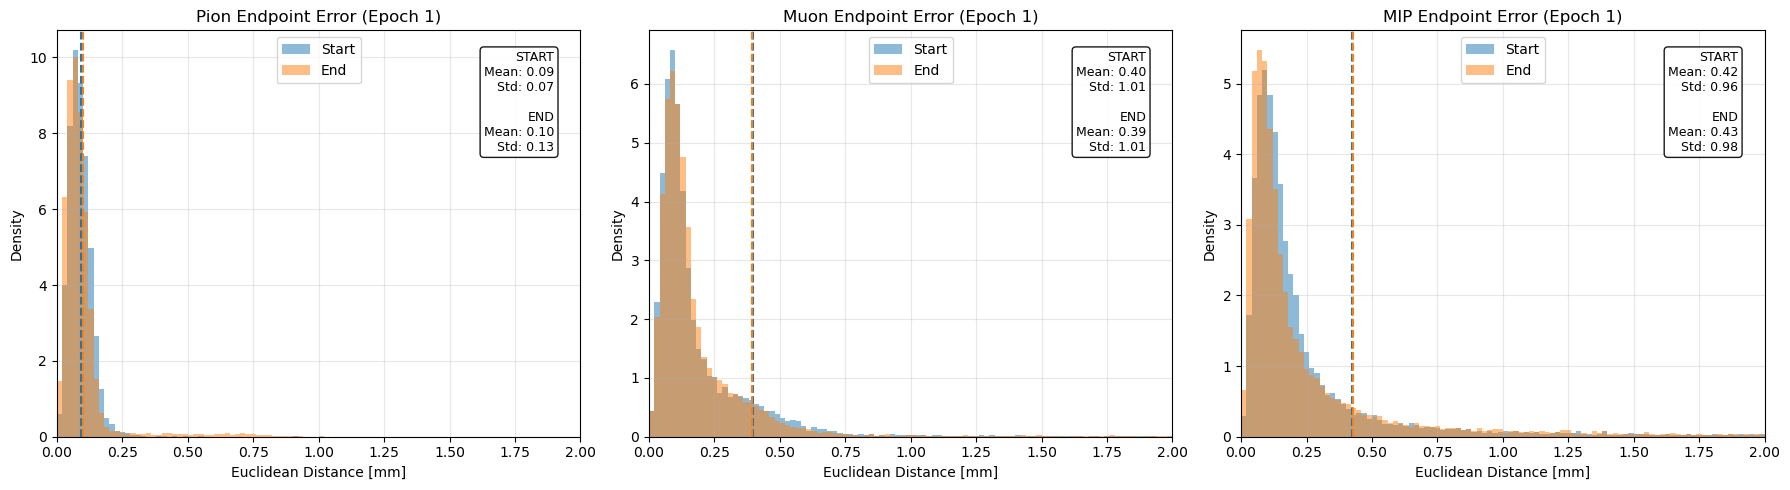

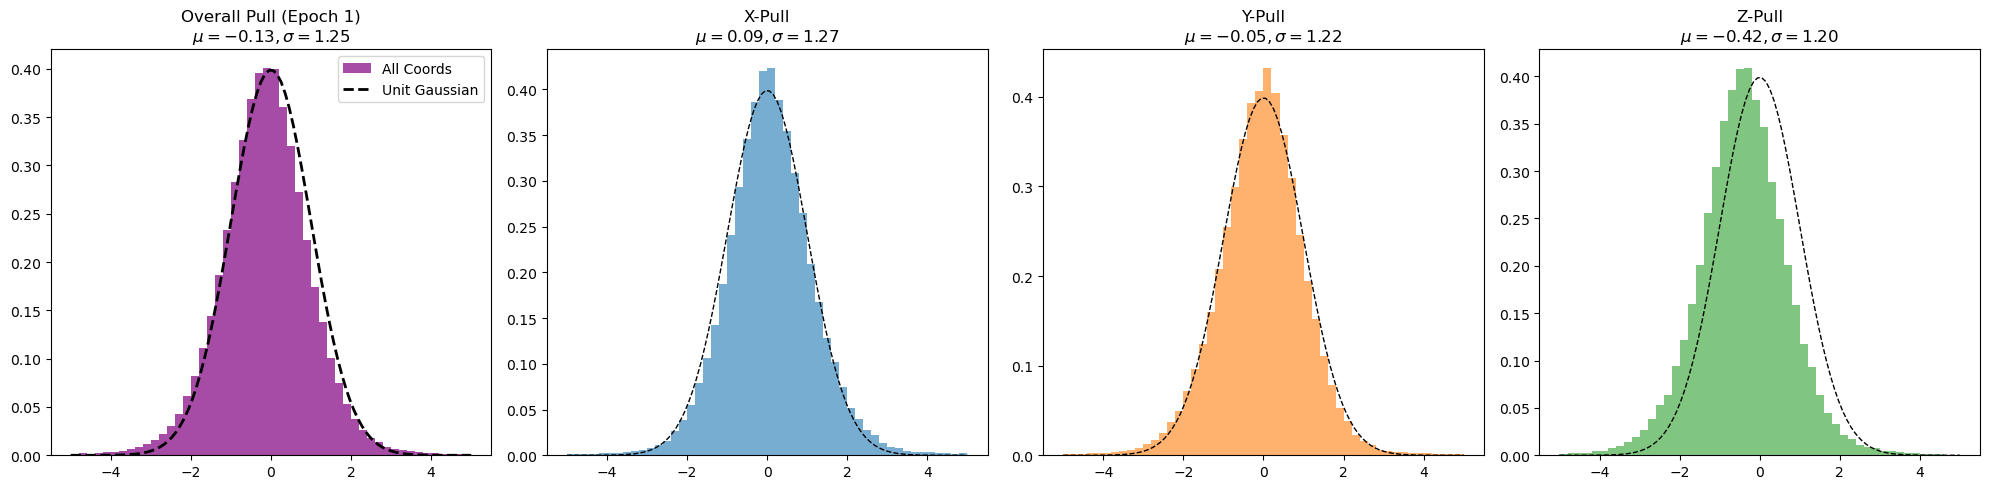

  Uncertainty Coverage (Expected 0.68): 0.6670
  Median Bias (Expected 0.50): 0.5495
New best model saved! (Loss: -16.5447)


Epoch 02 | Train Loss: -17.7393 | Mean Error: 0.2986
         | PosLoss: -17.7795 | SpanLoss: 0.3948 | DirLoss: 0.0007 | MeanWidth: 0.2592


         | Val Loss: -18.6626 | Val Error: 0.2879
         | PosLoss: -18.7010 | SpanLoss: 0.3833 | DirLoss: 0.0000 | MeanWidth: 0.2567


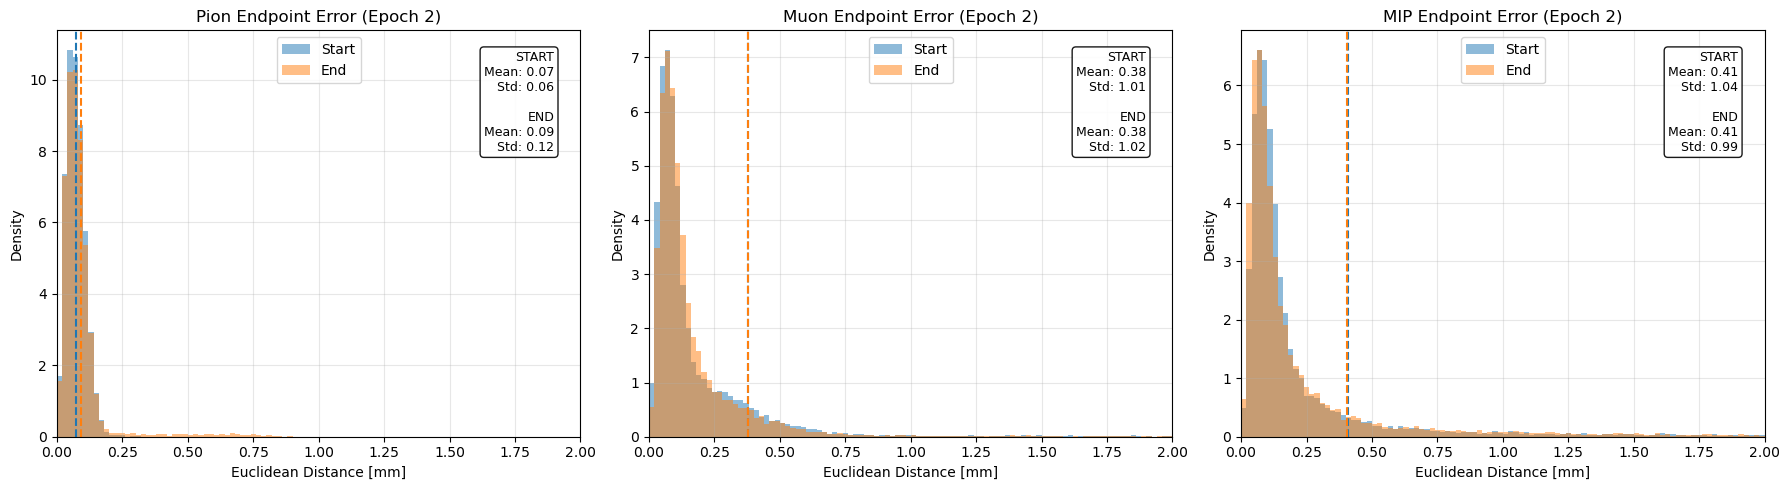

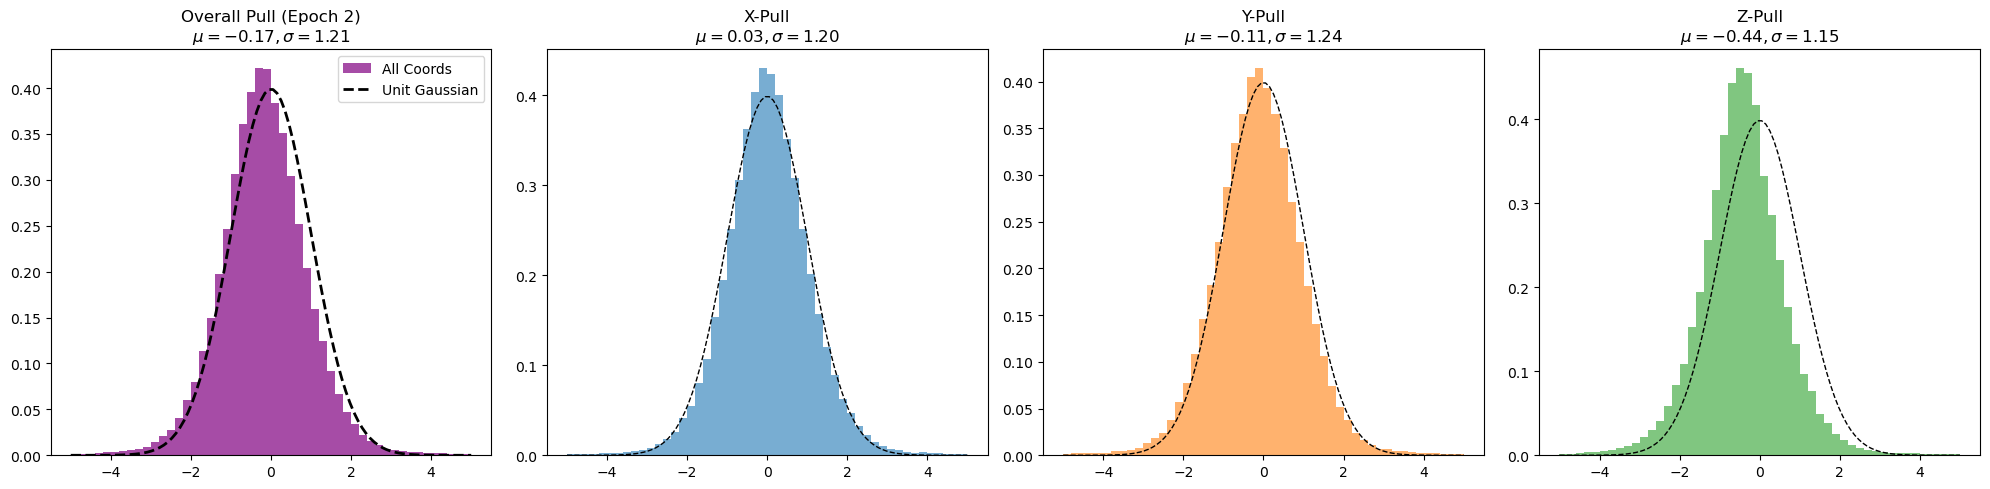

  Uncertainty Coverage (Expected 0.68): 0.6770
  Median Bias (Expected 0.50): 0.5793
New best model saved! (Loss: -18.6626)


Epoch 03 | Train Loss: -19.3354 | Mean Error: 0.2791
         | PosLoss: -19.3668 | SpanLoss: 0.3077 | DirLoss: 0.0007 | MeanWidth: 0.2387


         | Val Loss: -20.1692 | Val Error: 0.2686
         | PosLoss: -20.1955 | SpanLoss: 0.2629 | DirLoss: 0.0000 | MeanWidth: 0.2311


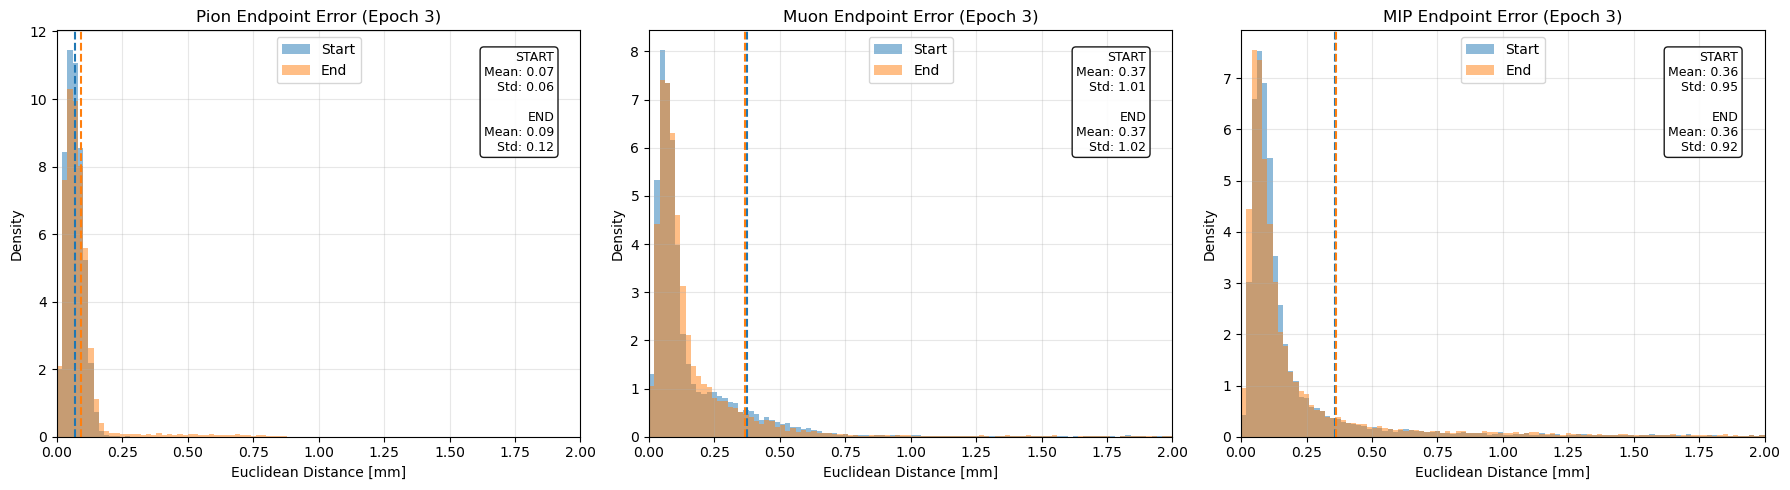

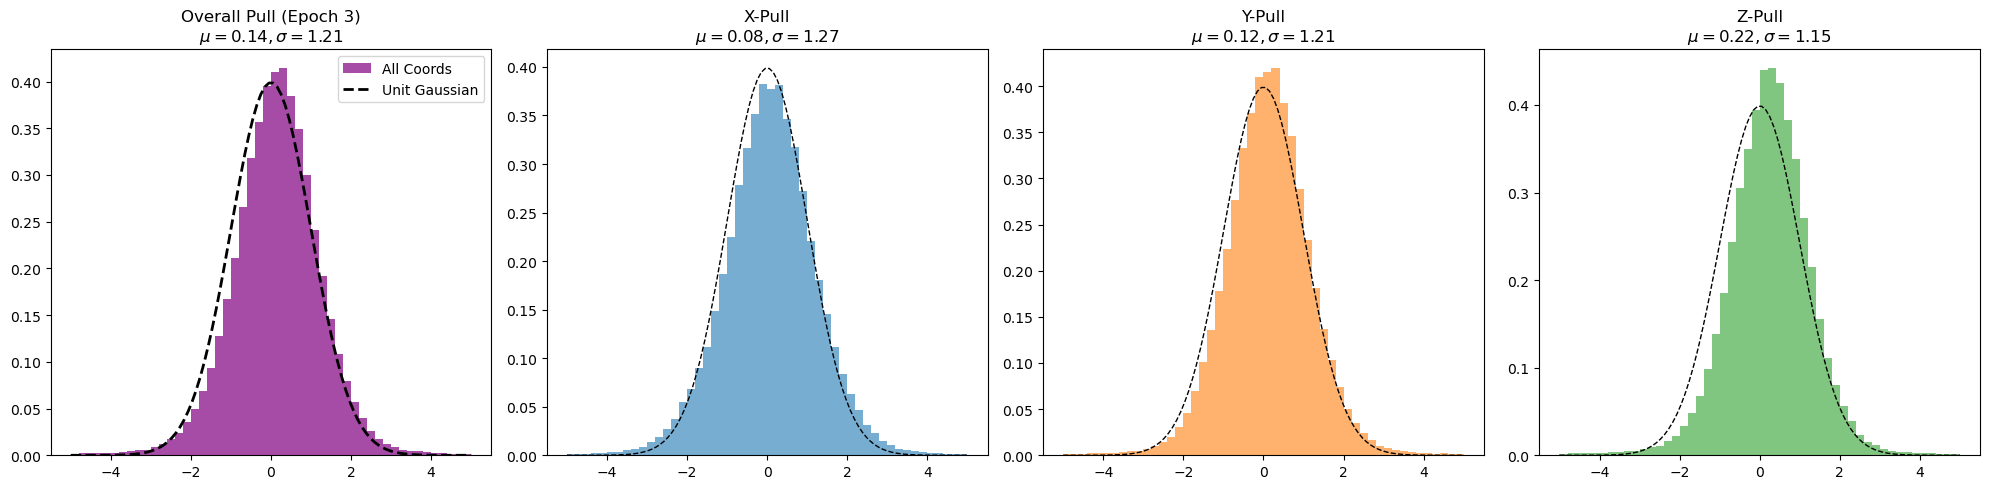

  Uncertainty Coverage (Expected 0.68): 0.6788
  Median Bias (Expected 0.50): 0.4374
New best model saved! (Loss: -20.1692)


Epoch 04 | Train Loss: -20.1883 | Mean Error: 0.2731
         | PosLoss: -20.2178 | SpanLoss: 0.2889 | DirLoss: 0.0006 | MeanWidth: 0.2326


         | Val Loss: -20.9955 | Val Error: 0.2610
         | PosLoss: -21.0218 | SpanLoss: 0.2626 | DirLoss: 0.0000 | MeanWidth: 0.2293


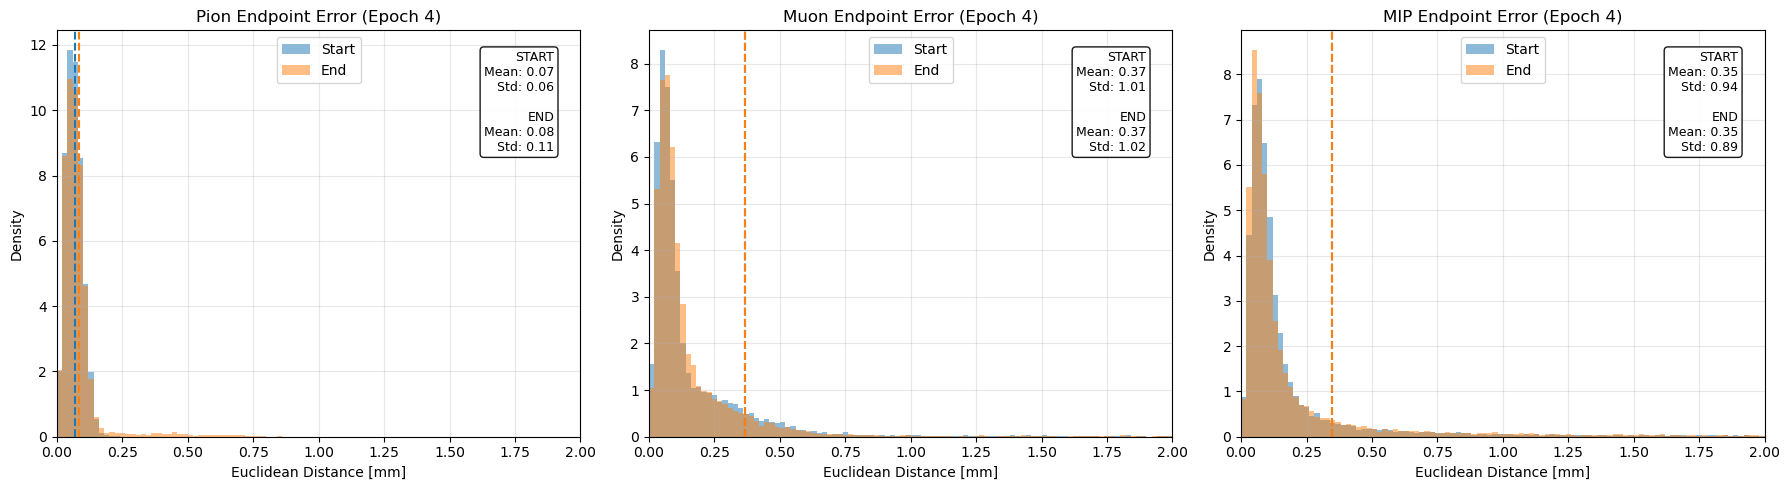

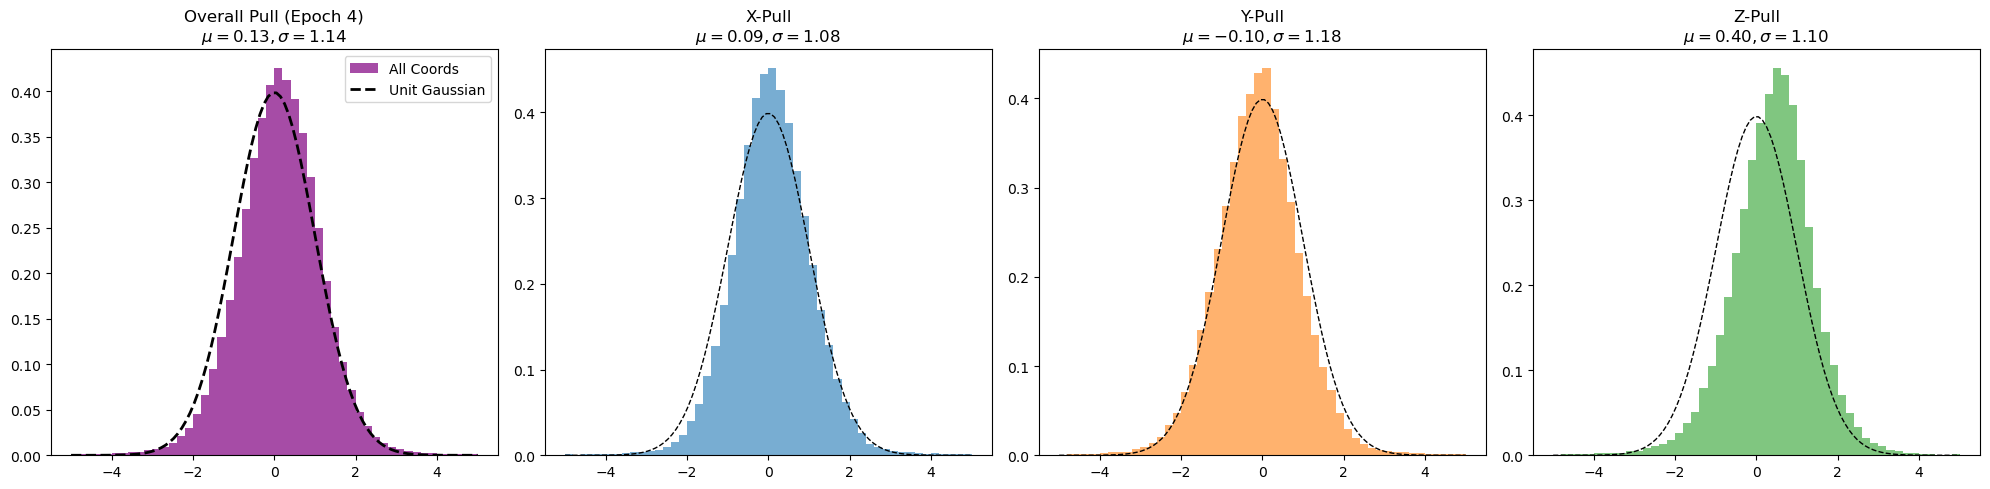

  Uncertainty Coverage (Expected 0.68): 0.6950
  Median Bias (Expected 0.50): 0.4411
New best model saved! (Loss: -20.9955)


Epoch 05 | Train Loss: -20.8005 | Mean Error: 0.2674
         | PosLoss: -20.8280 | SpanLoss: 0.2693 | DirLoss: 0.0006 | MeanWidth: 0.2280


         | Val Loss: -21.7770 | Val Error: 0.2557
         | PosLoss: -21.8014 | SpanLoss: 0.2437 | DirLoss: 0.0000 | MeanWidth: 0.2212


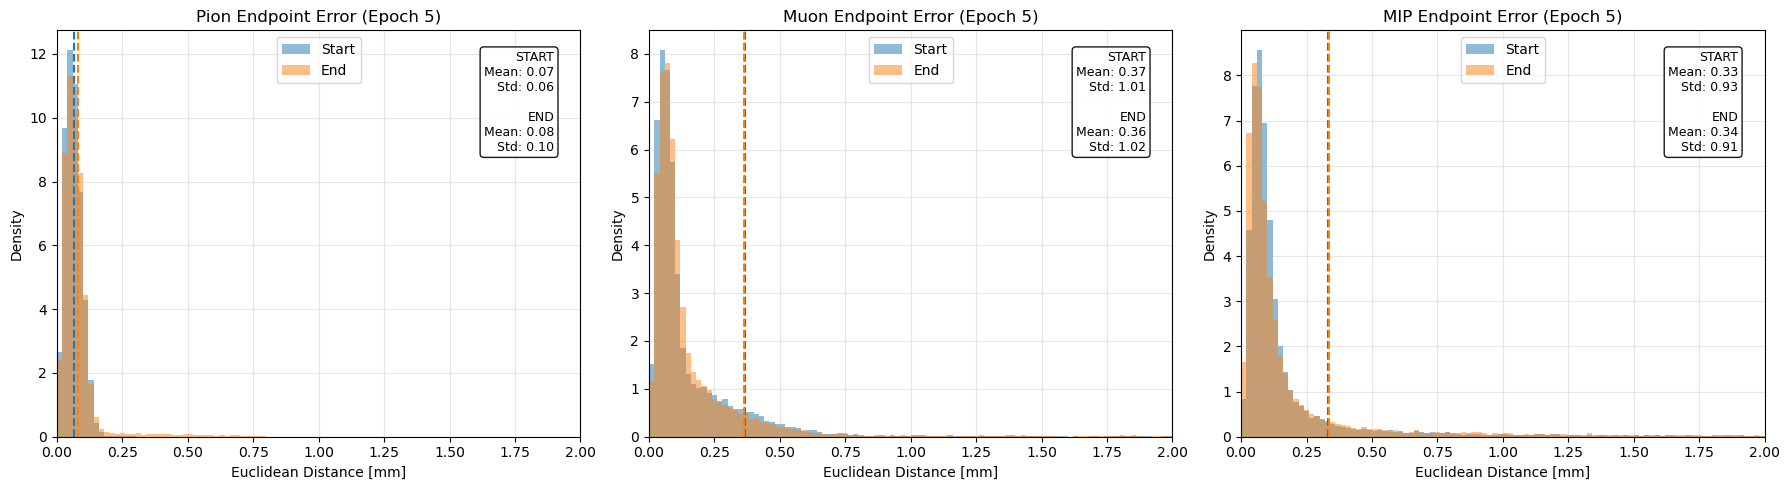

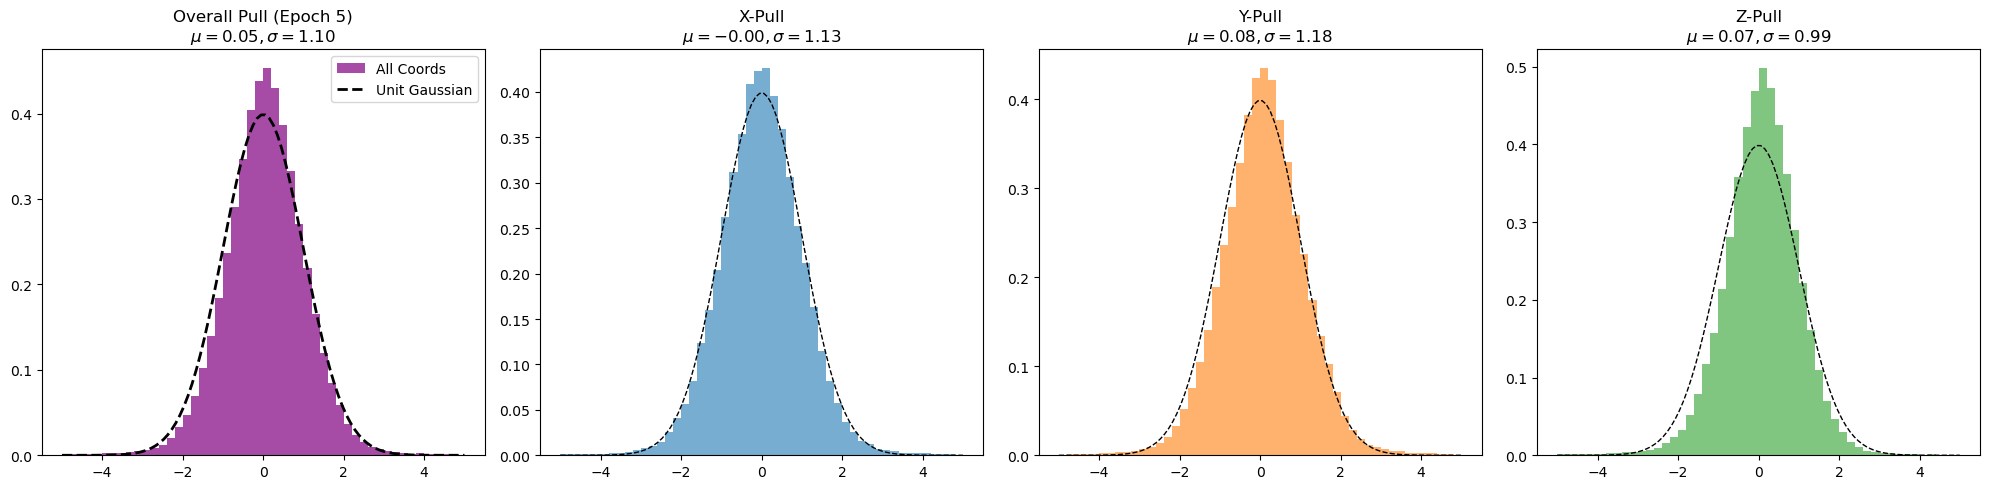

  Uncertainty Coverage (Expected 0.68): 0.7162
  Median Bias (Expected 0.50): 0.4731
New best model saved! (Loss: -21.7770)


Epoch 06 | Train Loss: -21.2352 | Mean Error: 0.2642
         | PosLoss: -21.2621 | SpanLoss: 0.2624 | DirLoss: 0.0006 | MeanWidth: 0.2256


         | Val Loss: -21.3871 | Val Error: 0.2569
         | PosLoss: -21.4113 | SpanLoss: 0.2419 | DirLoss: 0.0000 | MeanWidth: 0.2186


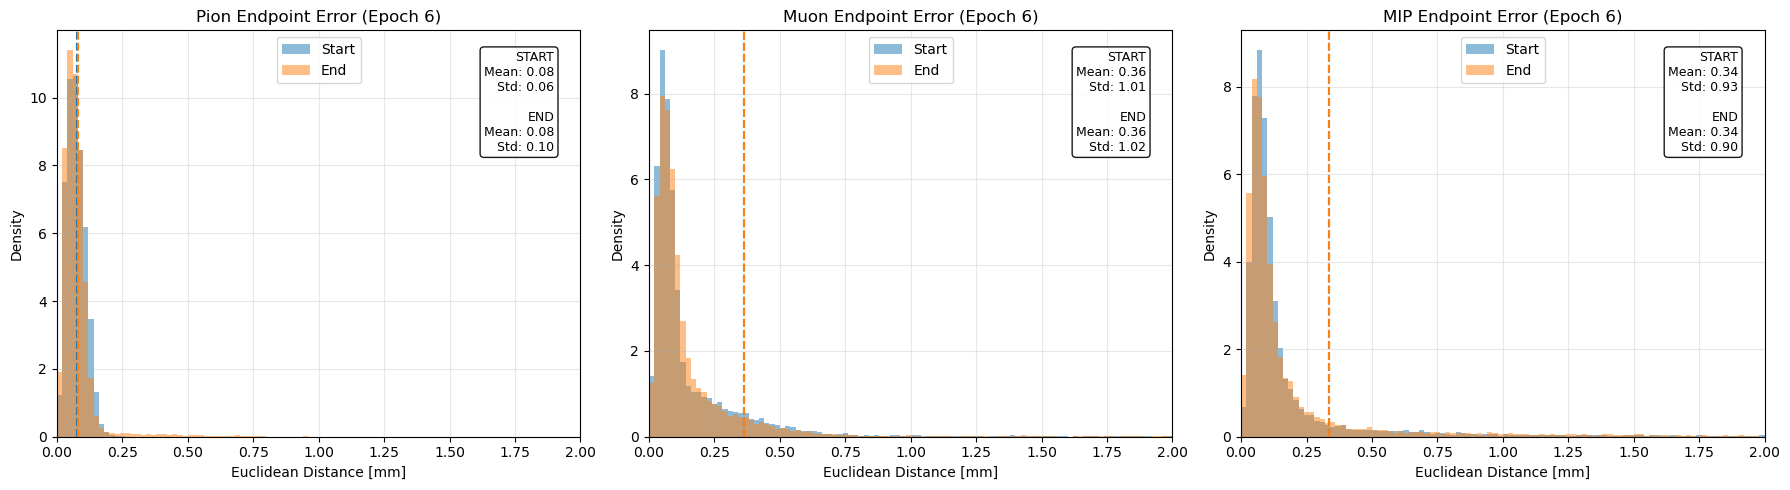

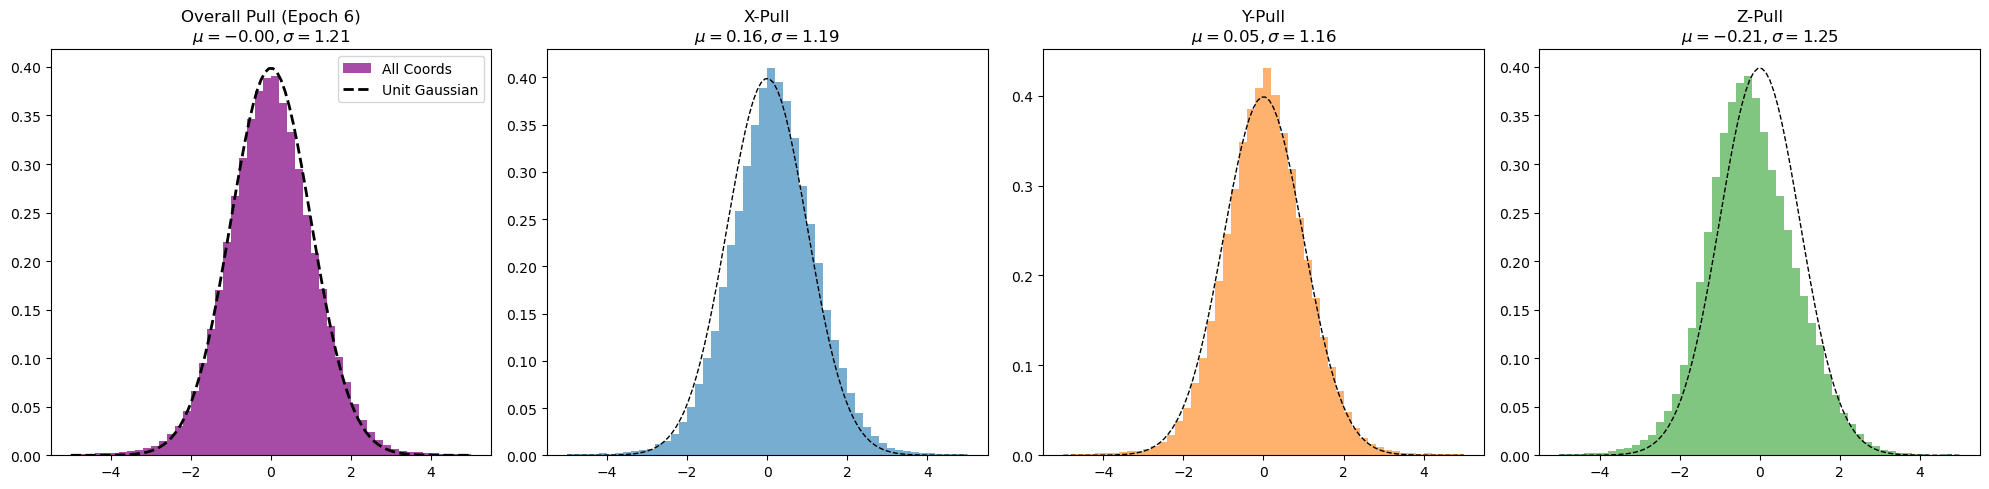

  Uncertainty Coverage (Expected 0.68): 0.6605
  Median Bias (Expected 0.50): 0.5035


Epoch 07 | Train Loss: -21.6445 | Mean Error: 0.2594
         | PosLoss: -21.6698 | SpanLoss: 0.2464 | DirLoss: 0.0006 | MeanWidth: 0.2215


         | Val Loss: -21.9450 | Val Error: 0.2514
         | PosLoss: -21.9675 | SpanLoss: 0.2253 | DirLoss: 0.0000 | MeanWidth: 0.2141


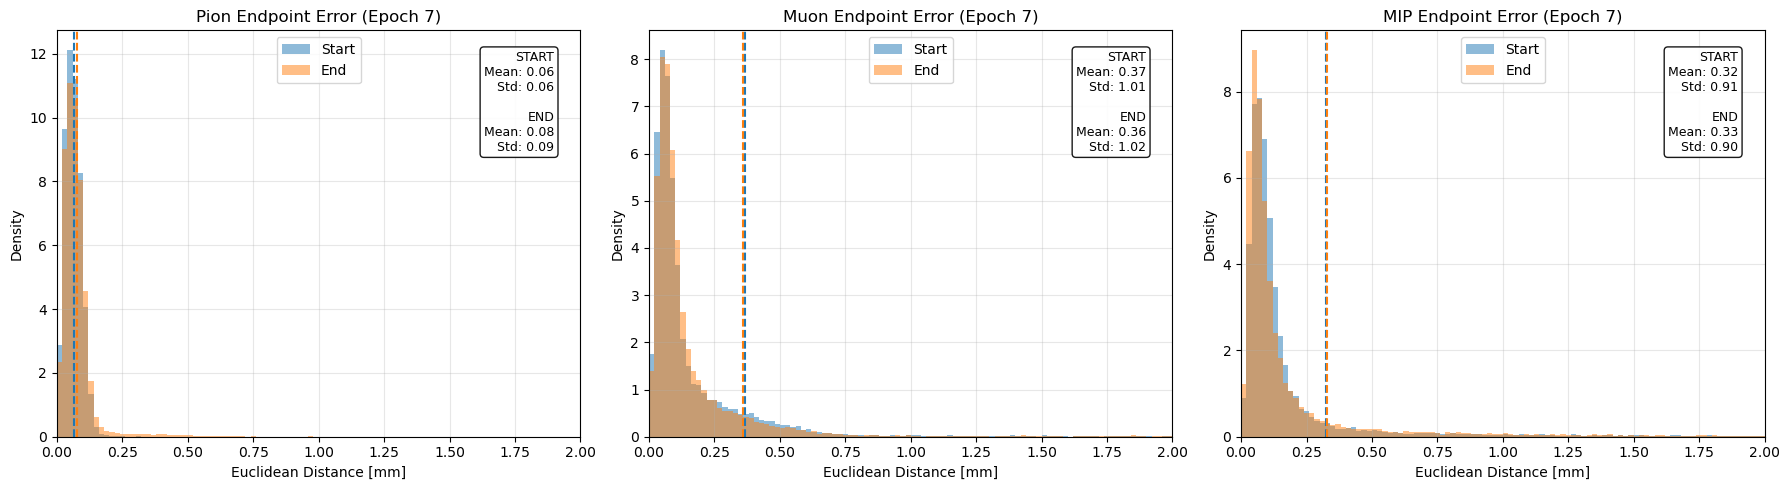

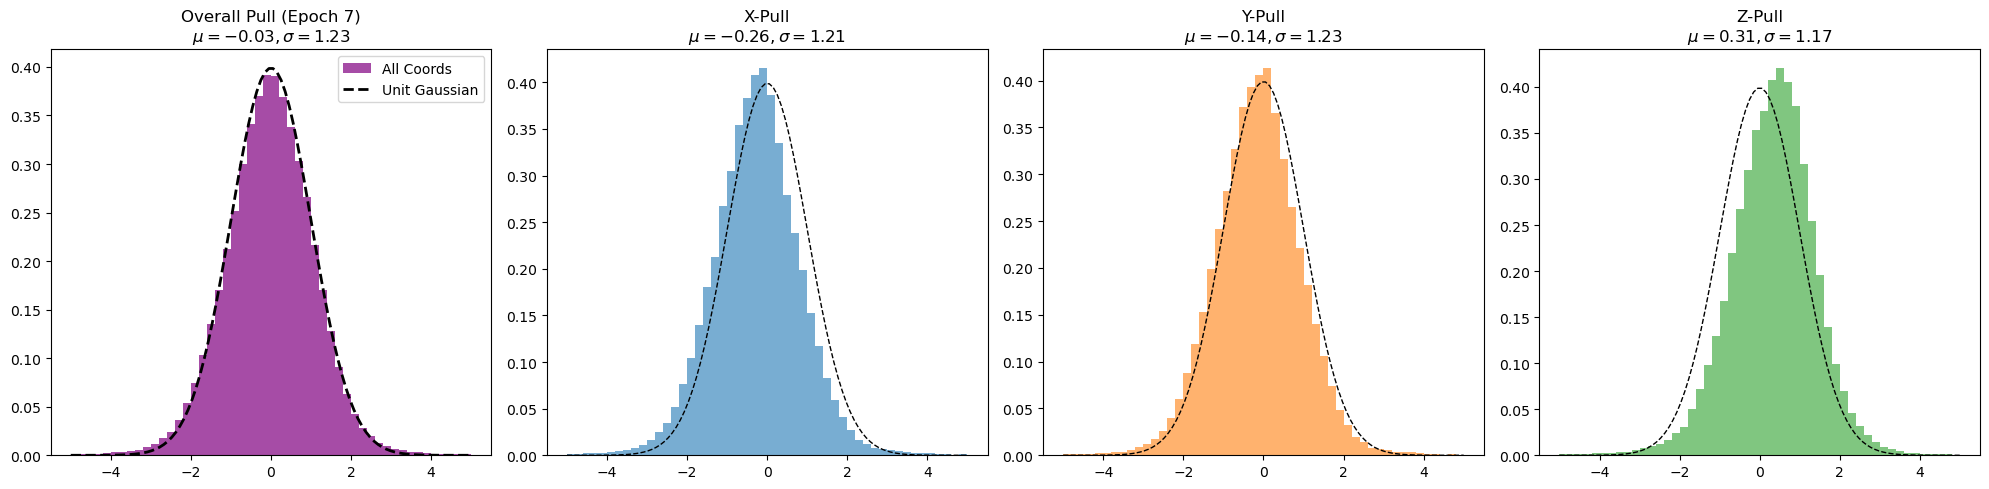

  Uncertainty Coverage (Expected 0.68): 0.6623
  Median Bias (Expected 0.50): 0.5053
New best model saved! (Loss: -21.9450)


KeyboardInterrupt: 

In [21]:
train_model(records, model, device=DEVICE, epochs=10, lr=1e-4, batch=32)

In [22]:
def visualize_uncertainties_safe(loader, model, device, num_events=5, target_class=None, shape='ellipse'):
    """
    Args:
        target_class (int): 0=Pion, 1=Muon, 2=MIP. Filter for specific particle type.
        shape (str): 'rect' or 'ellipse'.
    """
    model.train()
    all_mistakes = []
    class_map = {0: 'Pion', 1: 'Muon', 2: 'MIP'}
    with torch.no_grad():
        for batch in tqdm(loader, desc="Scanning...", leave=False):
            batch = batch.to(device)
            out = model(batch)
            target = batch.y_pos.view(-1, 2, 3)
            
            # Predictions
            pred_q16 = out[:, :, :, 0]
            pred_med = out[:, :, :, 1]
            pred_q84 = out[:, :, :, 2]
            
            # Error Calc (Median vs Target)
            d_direct = (pred_med - target).norm(dim=2).sum(dim=1)
            target_swapped = target[:, [1, 0], :]
            d_swapped = (pred_med - target_swapped).norm(dim=2).sum(dim=1)
            swap_mask = d_swapped < d_direct
            target_aligned = torch.where(swap_mask.view(-1, 1, 1), target_swapped, target)
            pos_error = (pred_med - target_aligned).norm(dim=2)
            # Iterate
            data_list = batch.to_data_list()
            for i, data in enumerate(data_list):
                # --- FILTER BY CLASS ---
                if hasattr(data, 'y_group'):
                    cls_idx = data.y_group.argmax().item()
                    if target_class is not None and cls_idx != target_class: 
                        continue # Skip if not matching
                    cls_name = class_map.get(cls_idx, "Unknown")
                else:
                    cls_name = "Event"
                # Safe Reconstruction
                x_np = data.x.cpu().numpy()
                pdgs = data.y_node.cpu().numpy() if hasattr(data, 'y_node') else None
                rec = GraphRecord(
                    coord=x_np[:, 0], z=x_np[:, 1], energy=x_np[:, 2], view=x_np[:, 3],
                    hit_pdgs=pdgs,
                    true_start=target_aligned[i, 0].cpu().numpy(),
                    true_end=target_aligned[i, 1].cpu().numpy(),
                    event_id=data.event_id.item() if hasattr(data, 'event_id') else None
                )
                all_mistakes.append({
                    'error': pos_error[i].max().item(),
                    'record': rec,
                    'class': cls_name,
                    'p_med': pred_med[i].cpu().numpy(),
                    'q16': pred_q16[i].cpu().numpy(),
                    'q84': pred_q84[i].cpu().numpy()
                })
    all_mistakes.sort(key=lambda x: x['error'], reverse=True)
    print(f"Found {len(all_mistakes)} events. Plotting Top {num_events}...")
    for i in range(min(num_events, len(all_mistakes))):
        item = all_mistakes[i]
        
        # Base Plot
        fig = plot_event_display(
            [item['record']], 
            pred_points=[item['p_med']],
            title=f"Rank {i+1} | {item['class']} | MaxErr: {item['error']:.1f} mm",
            fixed_axes=True,
            show=False
        )
        
        # Draw Uncertainty
        if fig:
            axes = fig.axes
            for pt_idx in range(2): 
                # 1. Get raw values
                med = item['p_med'][pt_idx] # [x, y, z]
                q16 = item['q16'][pt_idx]
                q84 = item['q84'][pt_idx]
                
                # 2. Calculate Coverage Dimensions (The "Blob")
                # The width of the shape is simply the distance between quantiles
                width = q84 - q16 # [dx, dy, dz]
                
                # 3. Calculate Geometric Centers (The "Midpoint")
                # We must center the shape here so it touches q16 and q84 exactly
                geo_center = (q16 + q84) / 2.0
                
                # --- View 0 (X-Z): Plot Z vs X ---
                ax0 = axes[0]
                
                if shape == 'ellipse':
                    # Center at geometric midpoint (geo_center), not median (med)
                    patch0 = mpatches.Ellipse(
                        (geo_center[2], geo_center[0]), # Center (z_mid, x_mid)
                        width[2], width[0],             # Width (dz, dx)
                        edgecolor='red', facecolor='red', alpha=0.15
                    )
                else:
                    # Rectangle uses bottom-left corner, so q16 is already correct
                    patch0 = mpatches.Rectangle(
                        (q16[2], q16[0]),               # Corner (z_min, x_min)
                        width[2], width[0], 
                        edgecolor='red', facecolor='red', alpha=0.15
                    )
                
                ax0.add_patch(patch0)
                # OPTIONAL: Plot the median explicitly to show the asymmetry
                ax0.scatter(med[2], med[0], marker='+', color='black', s=50)

                # --- View 1 (Y-Z): Plot Z vs Y ---
                ax1 = axes[1]
                
                if shape == 'ellipse':
                    patch1 = mpatches.Ellipse(
                        (geo_center[2], geo_center[1]), # Center (z_mid, y_mid)
                        width[2], width[1],             # Width (dz, dy)
                        edgecolor='red', facecolor='red', alpha=0.15
                    )
                else:
                    patch1 = mpatches.Rectangle(
                        (q16[2], q16[1]), 
                        width[2], width[1], 
                        edgecolor='red', facecolor='red', alpha=0.15
                    )
                    
                ax1.add_patch(patch1)
                # OPTIONAL: Plot the median explicitly
                ax1.scatter(med[2], med[1], marker='+', color='black', s=50)
            
            plt.show()

In [28]:
test_dataset = GraphGroupDataset(records[:100])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Found 35 events. Plotting Top 30...


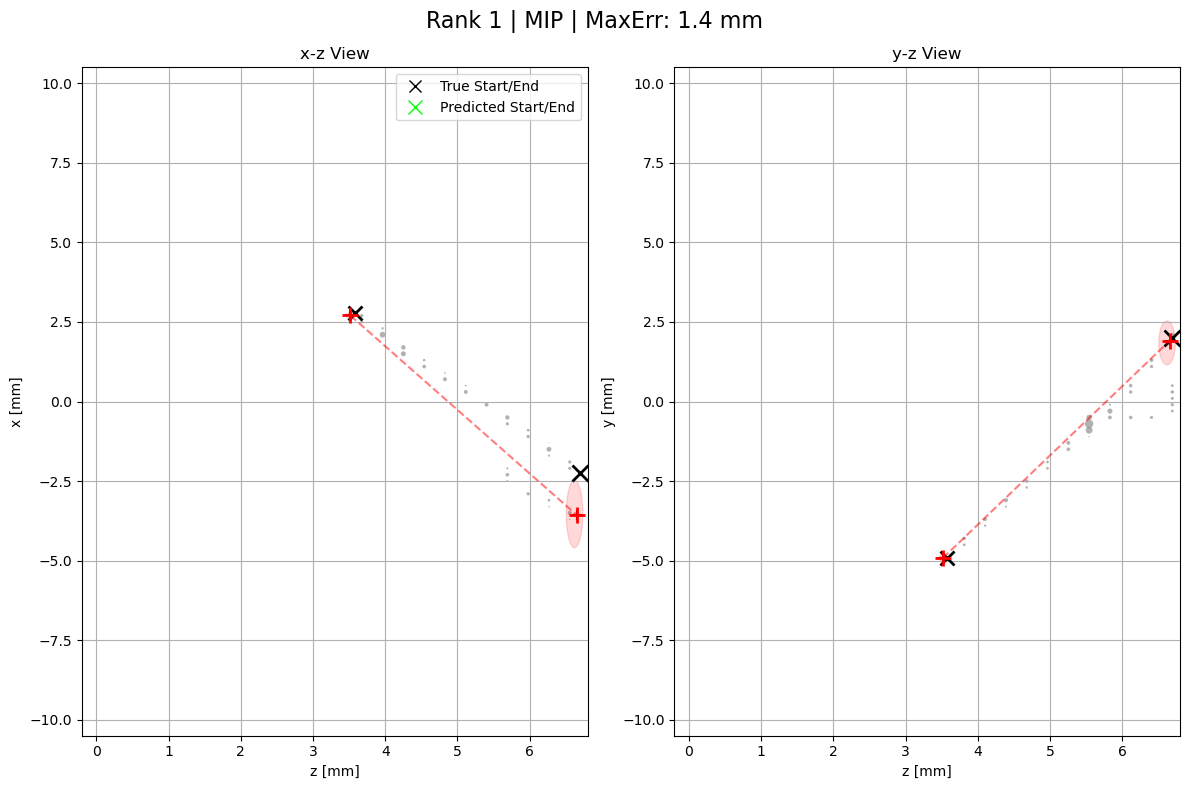

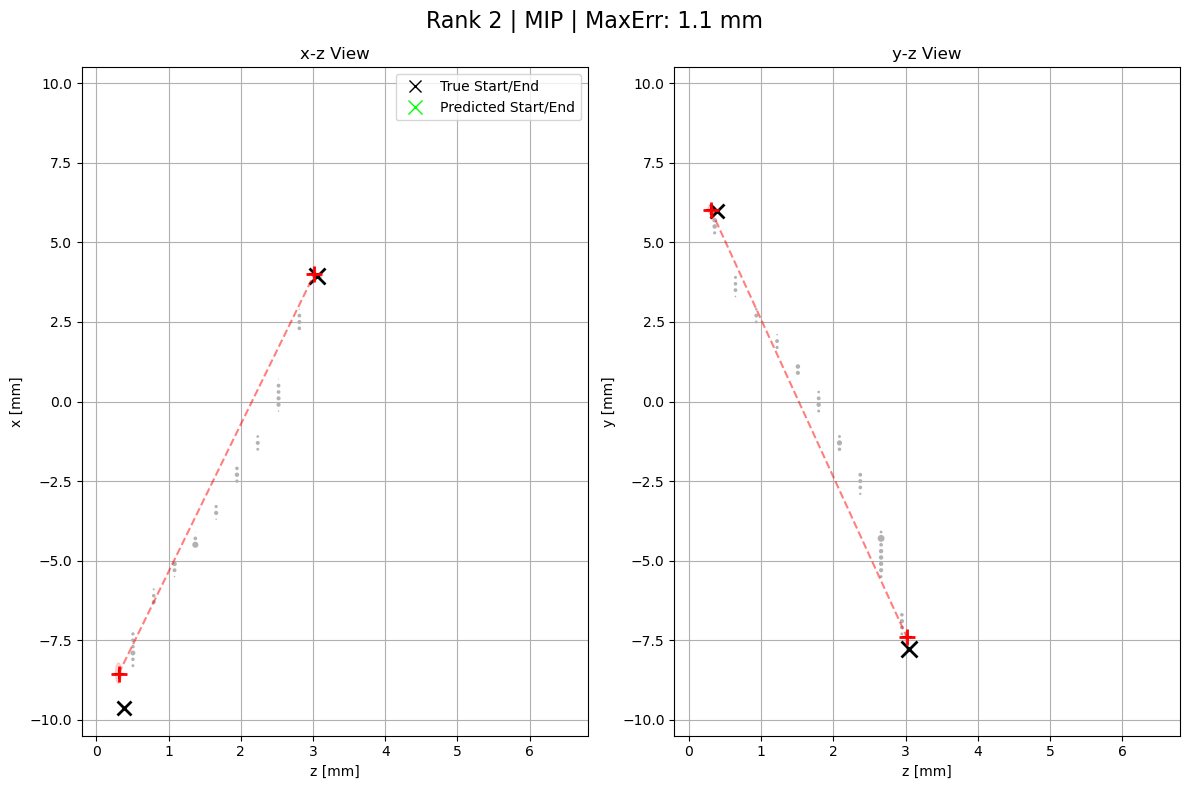

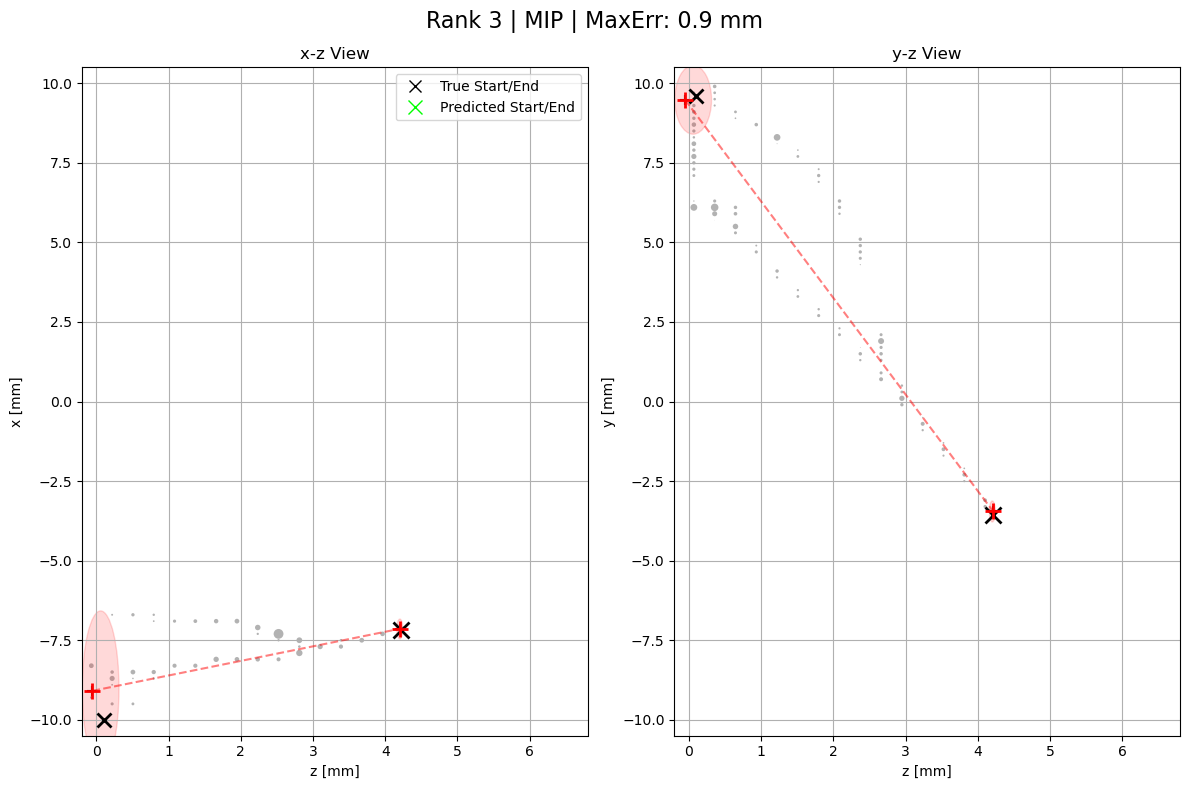

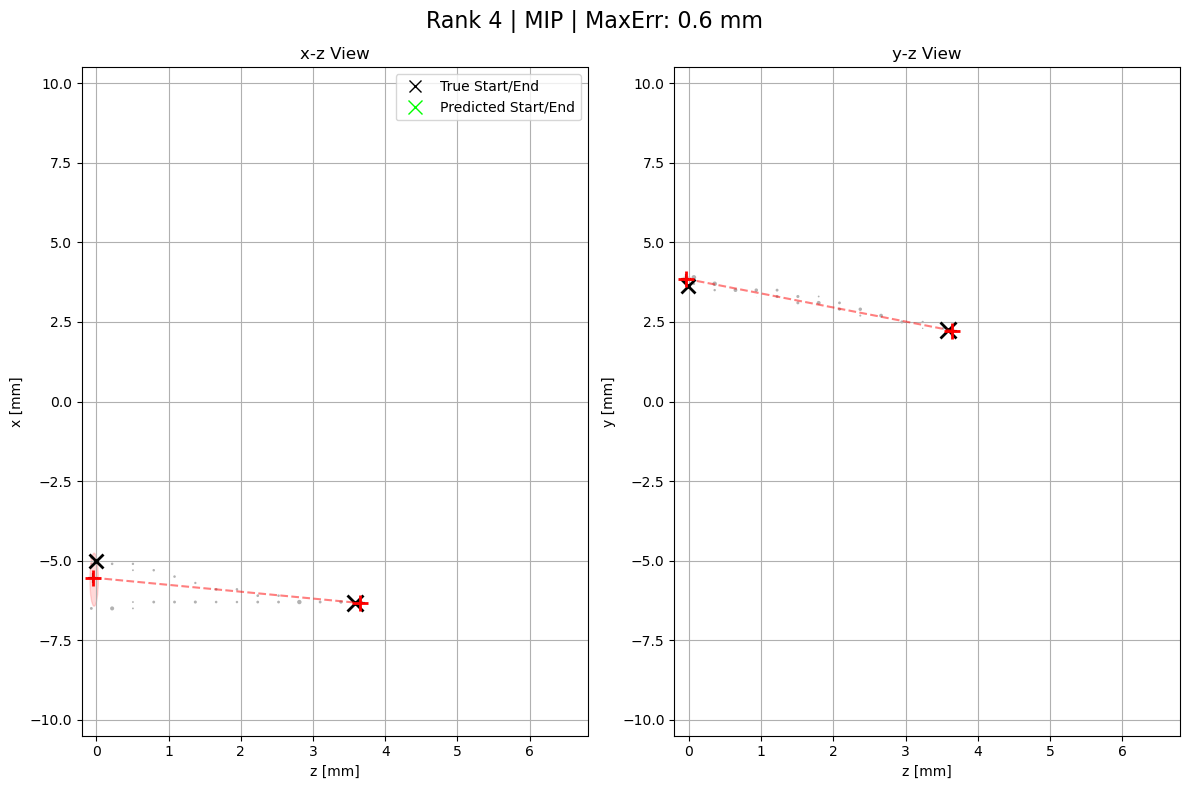

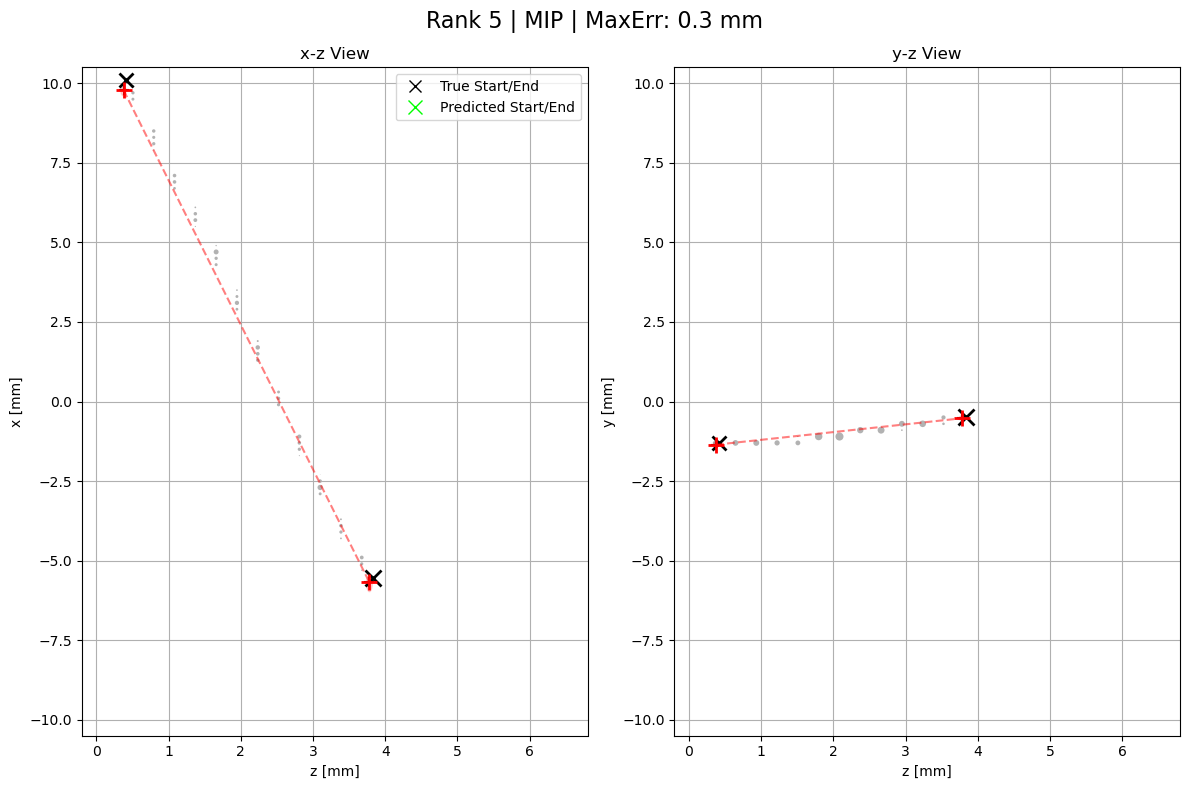

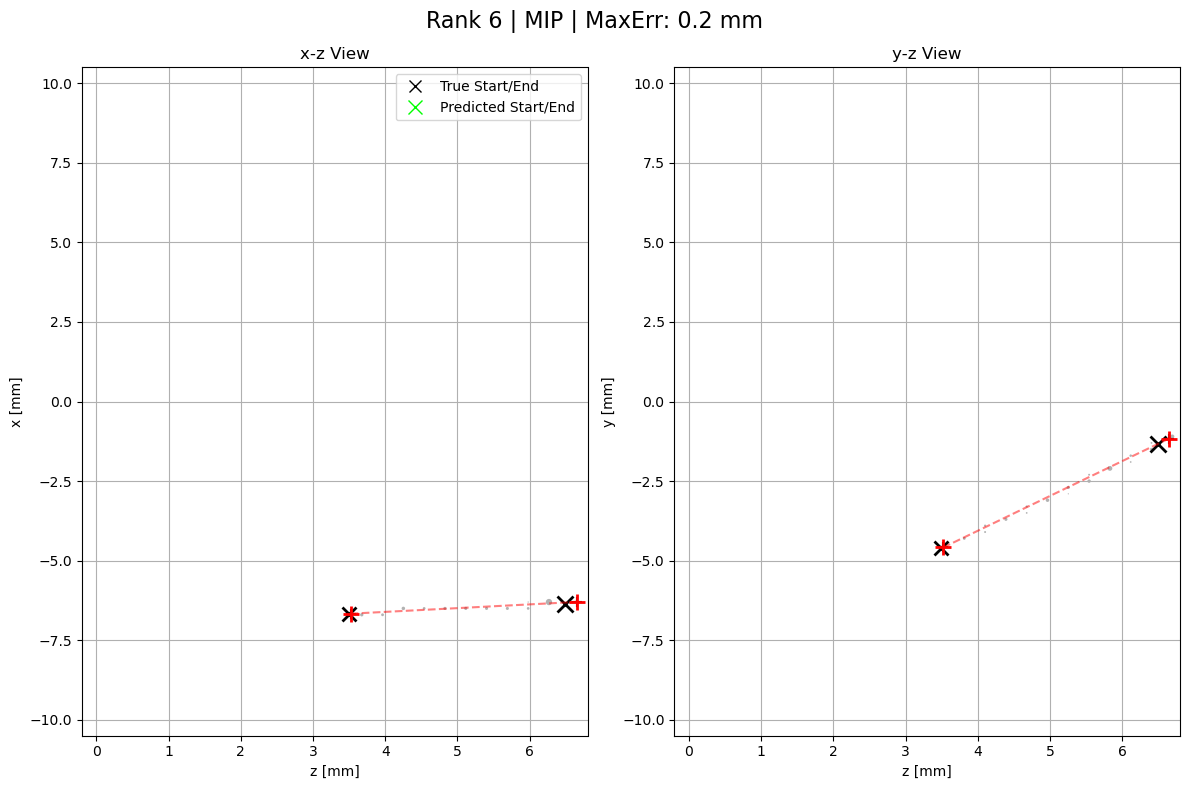

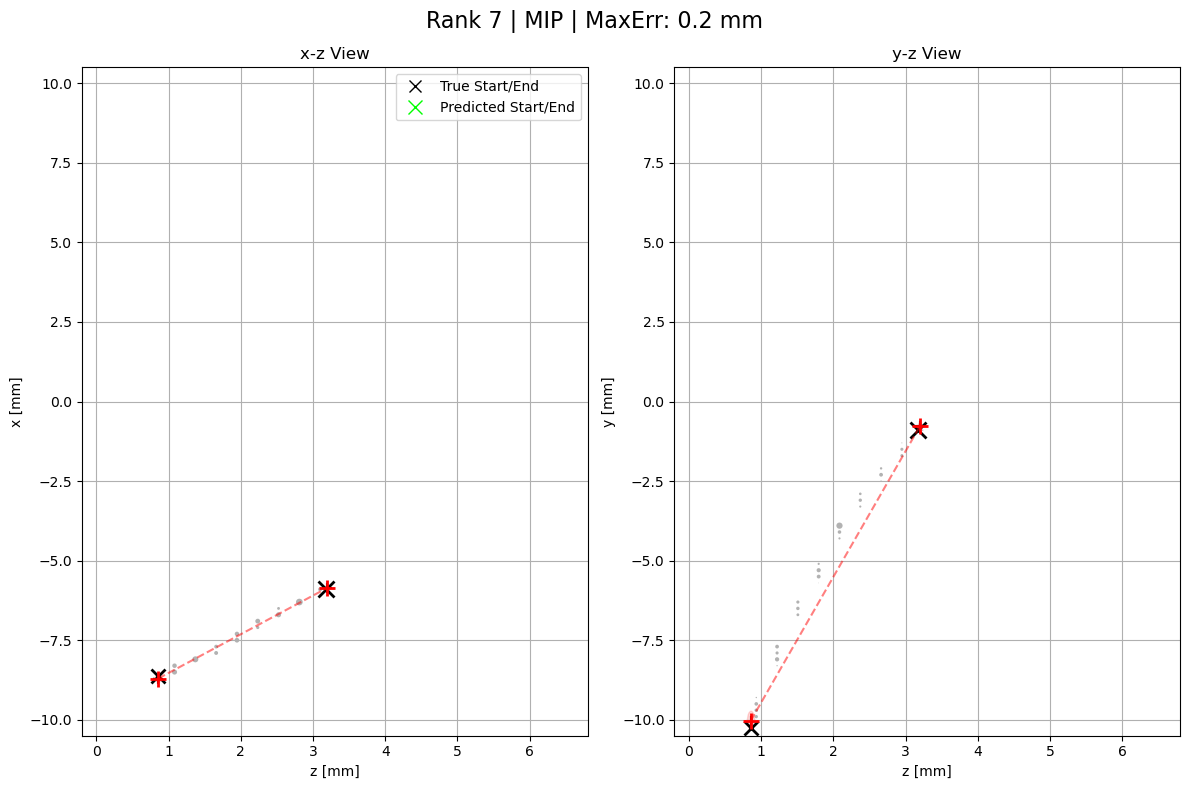

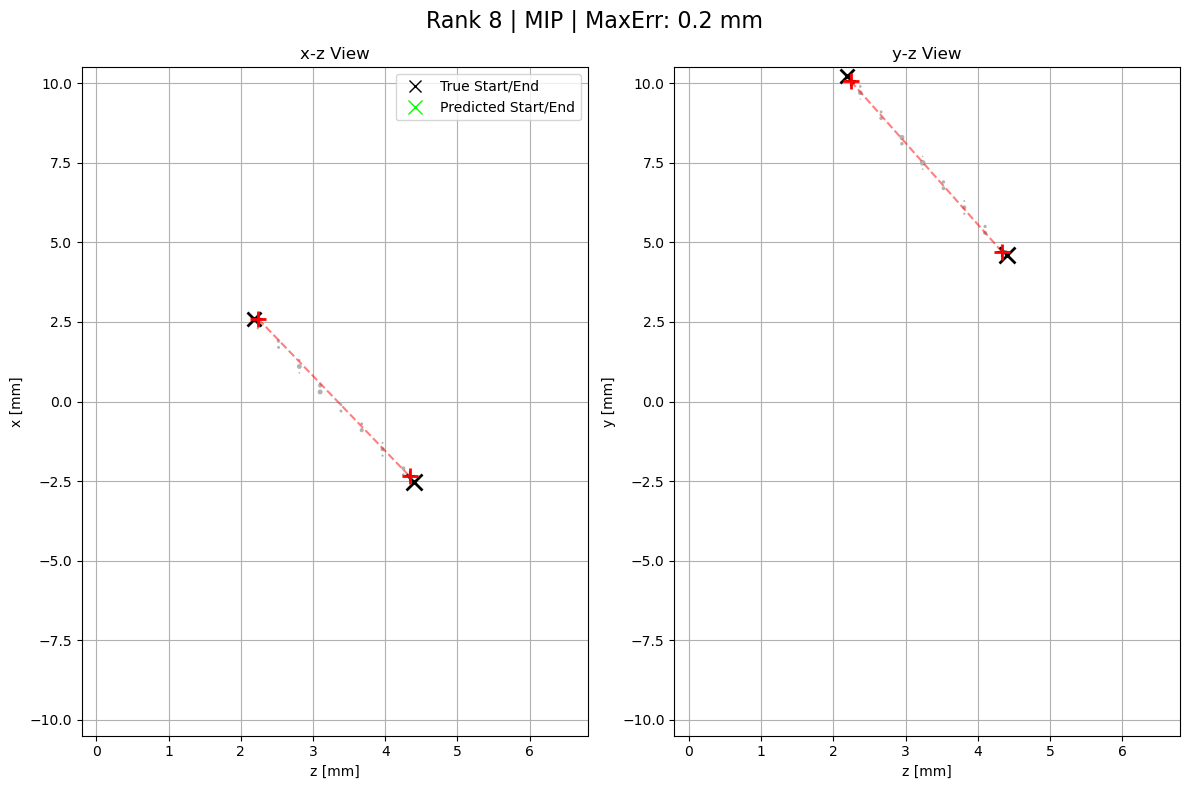

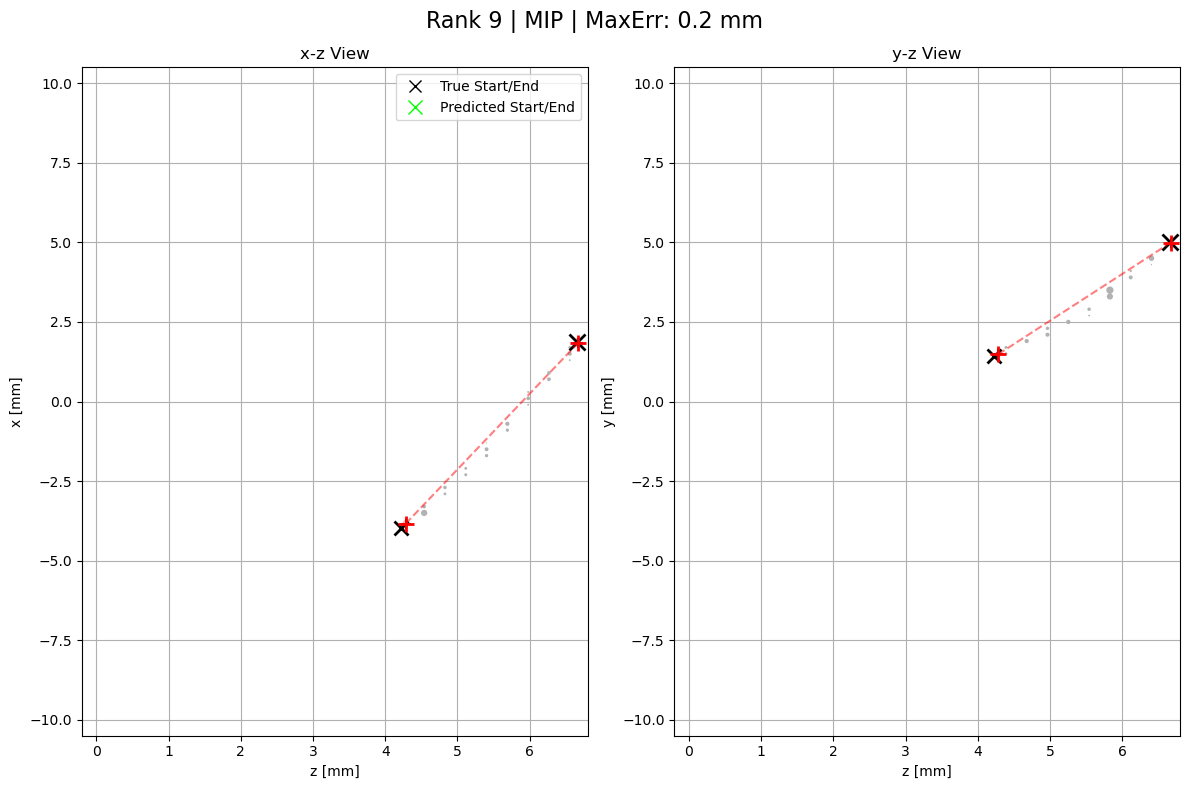

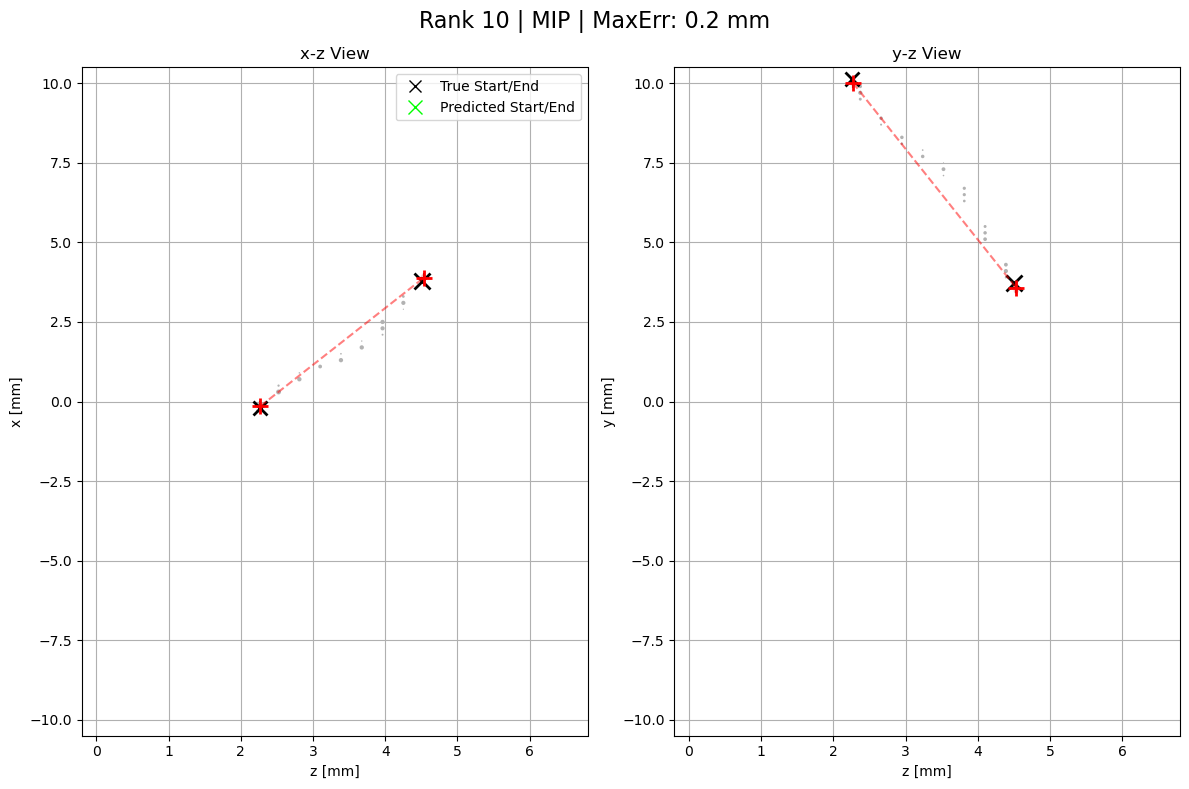

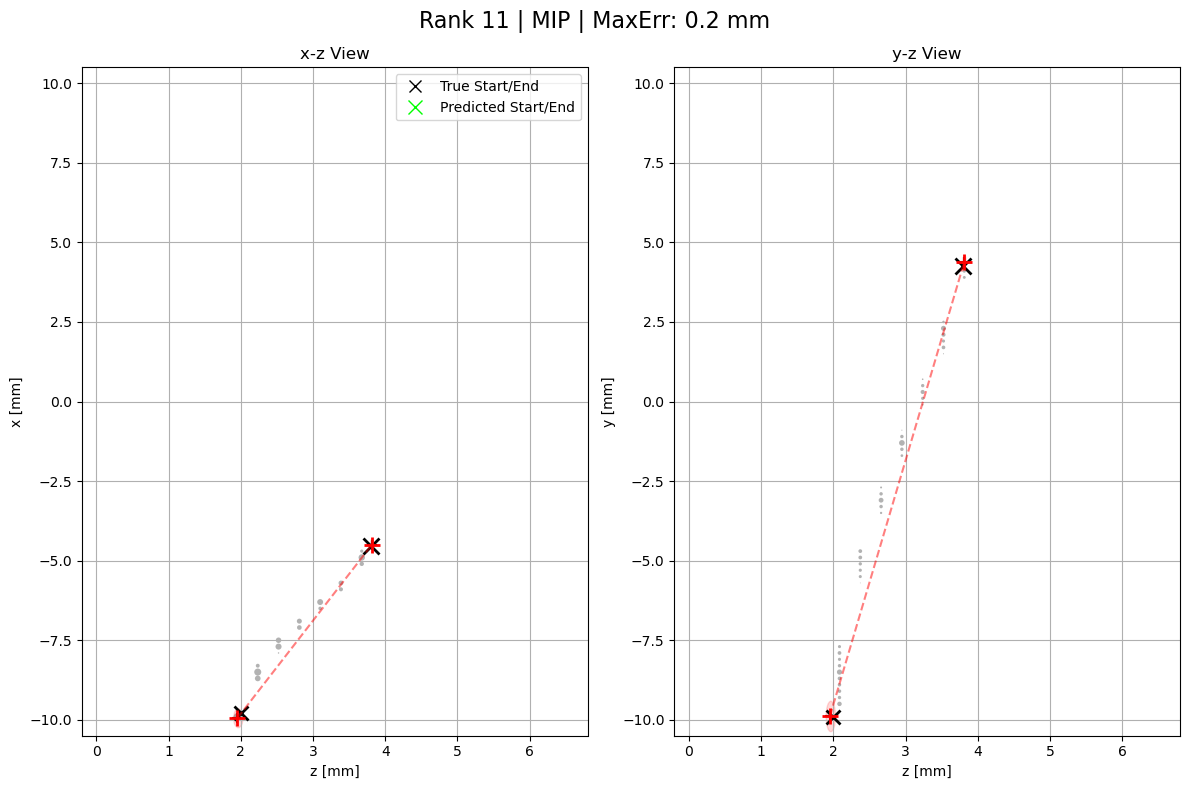

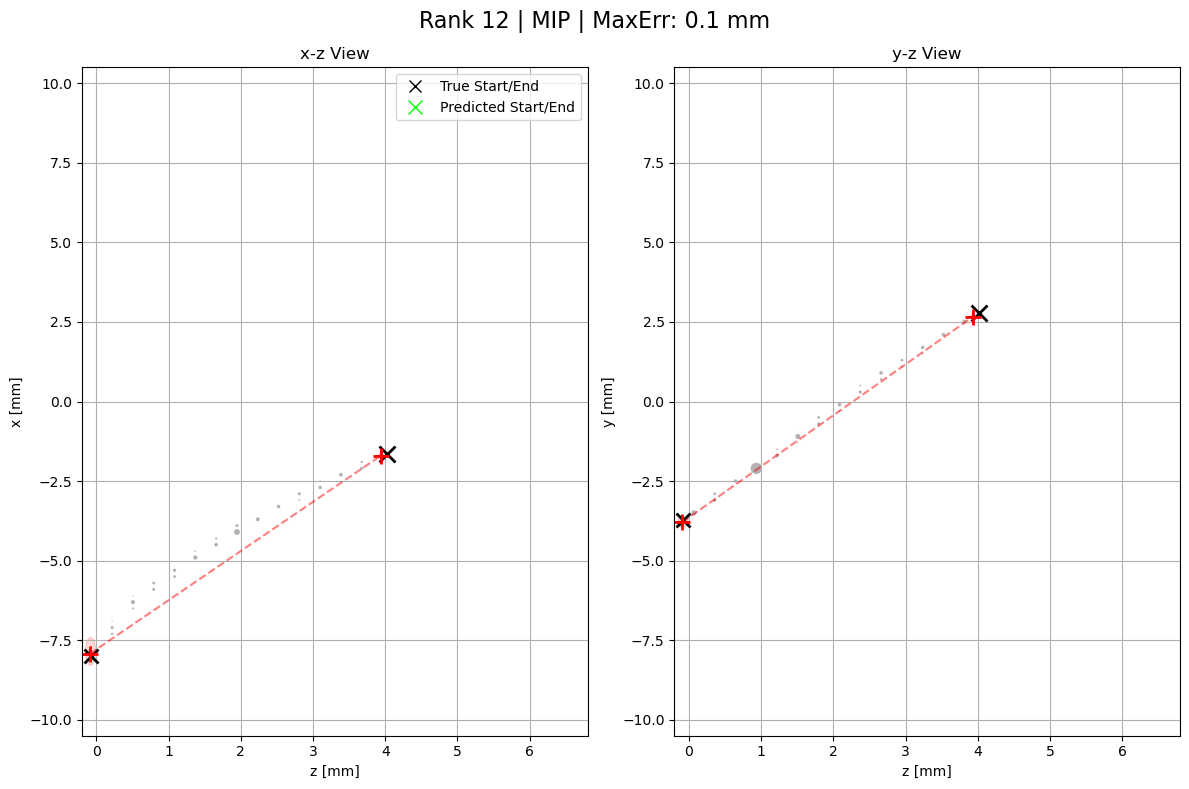

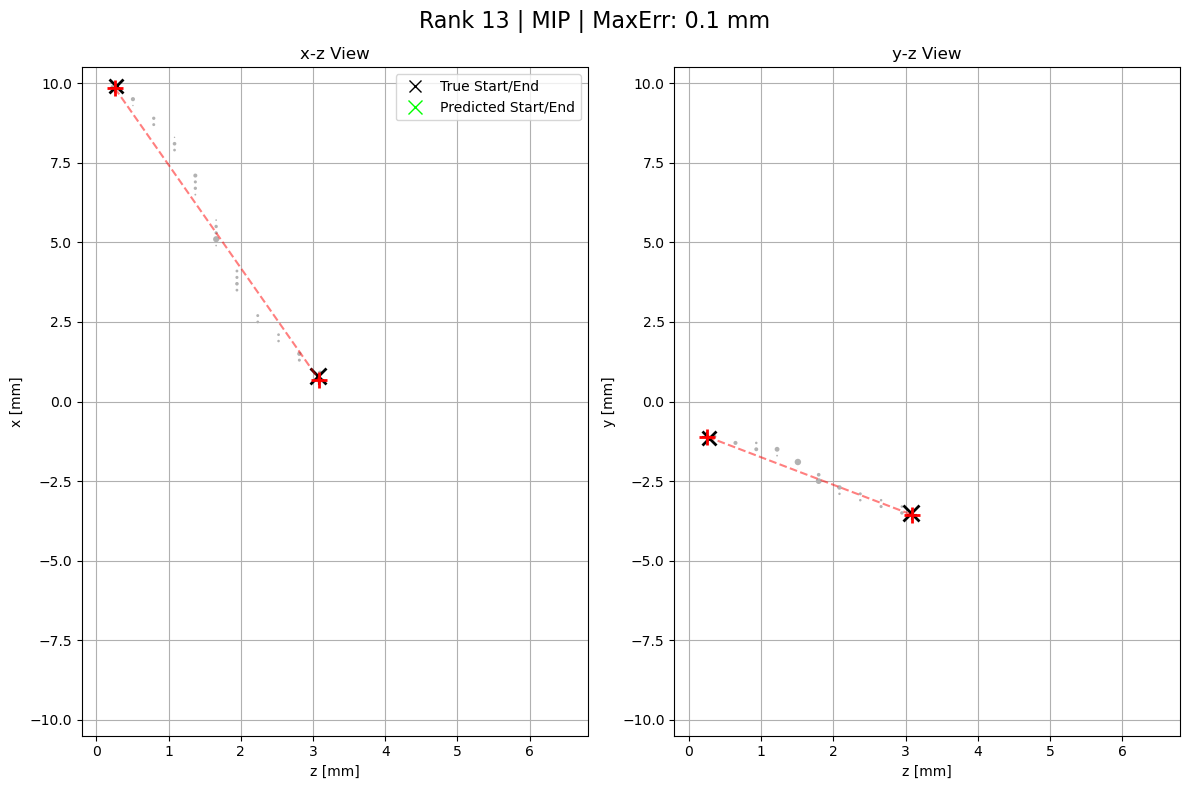

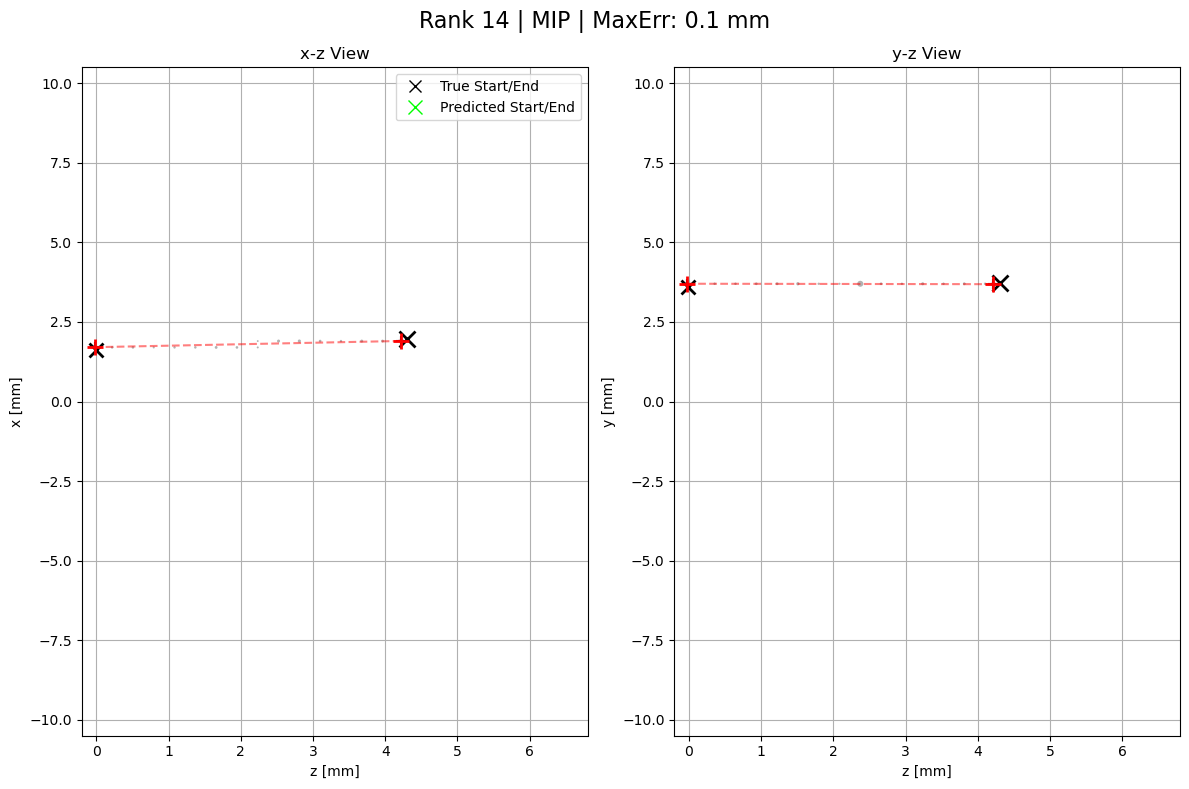

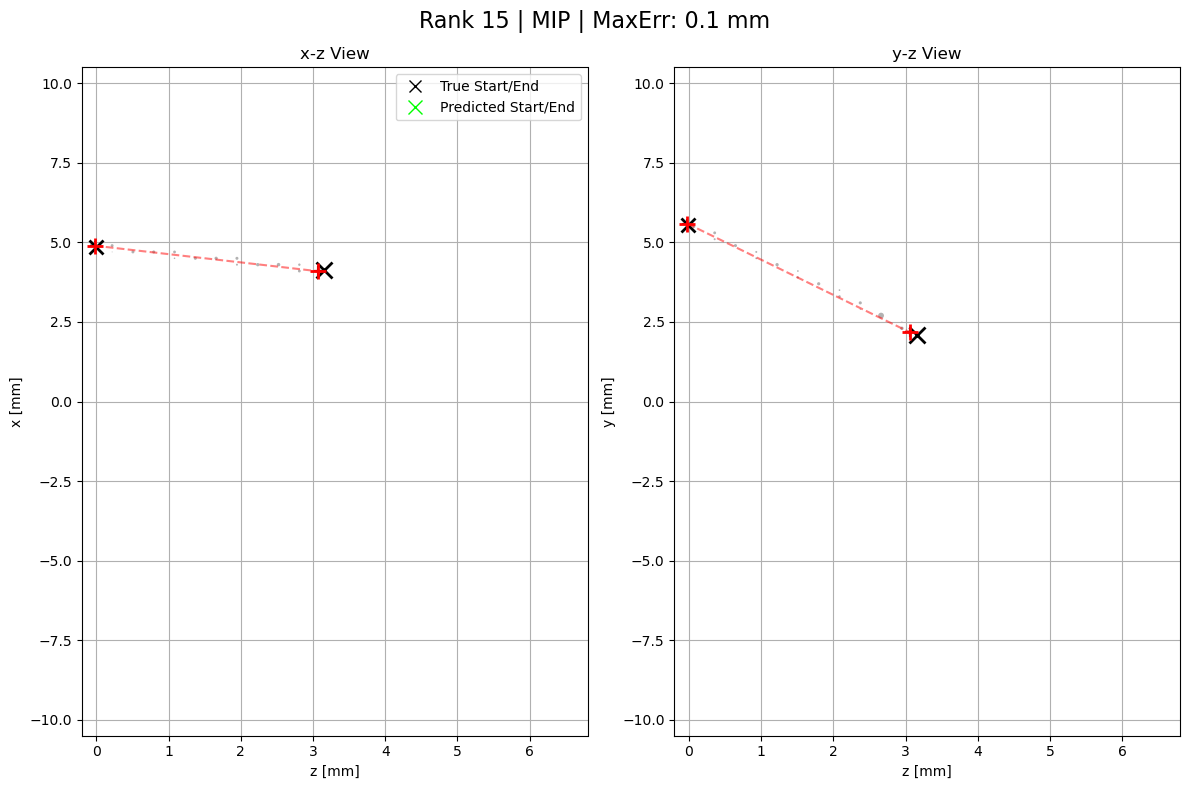

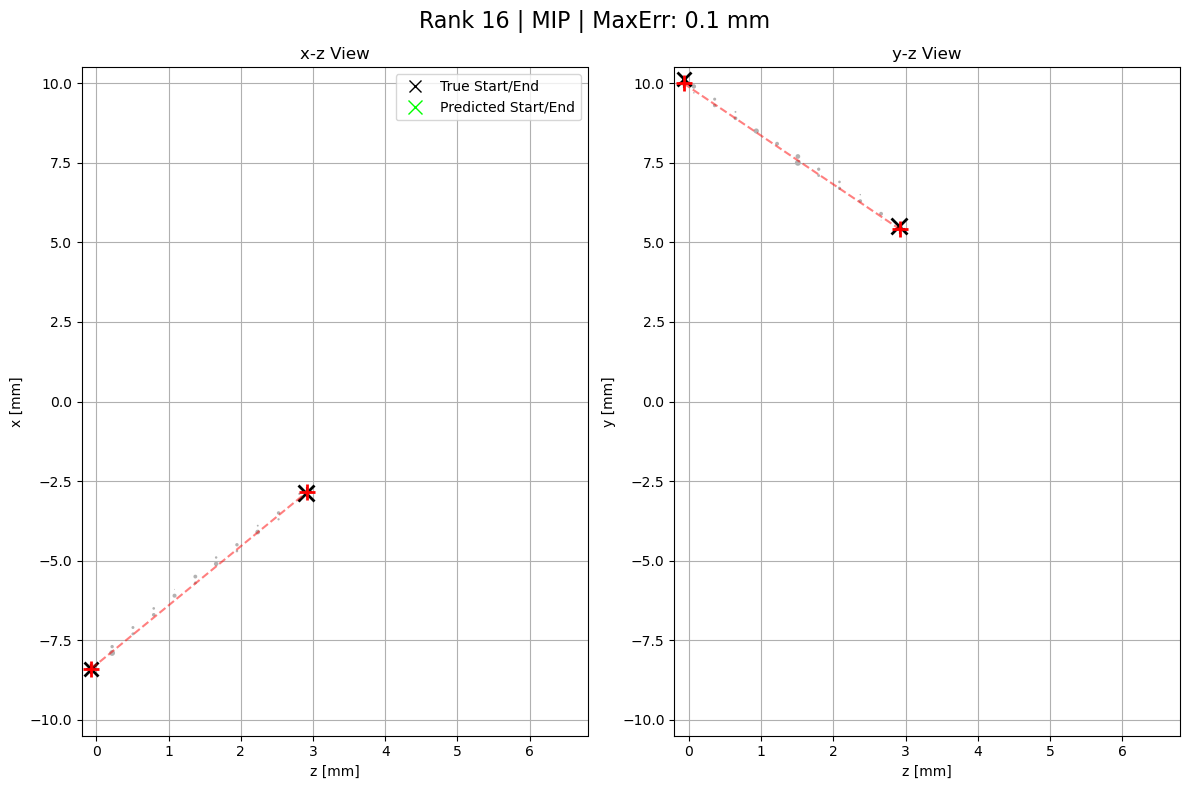

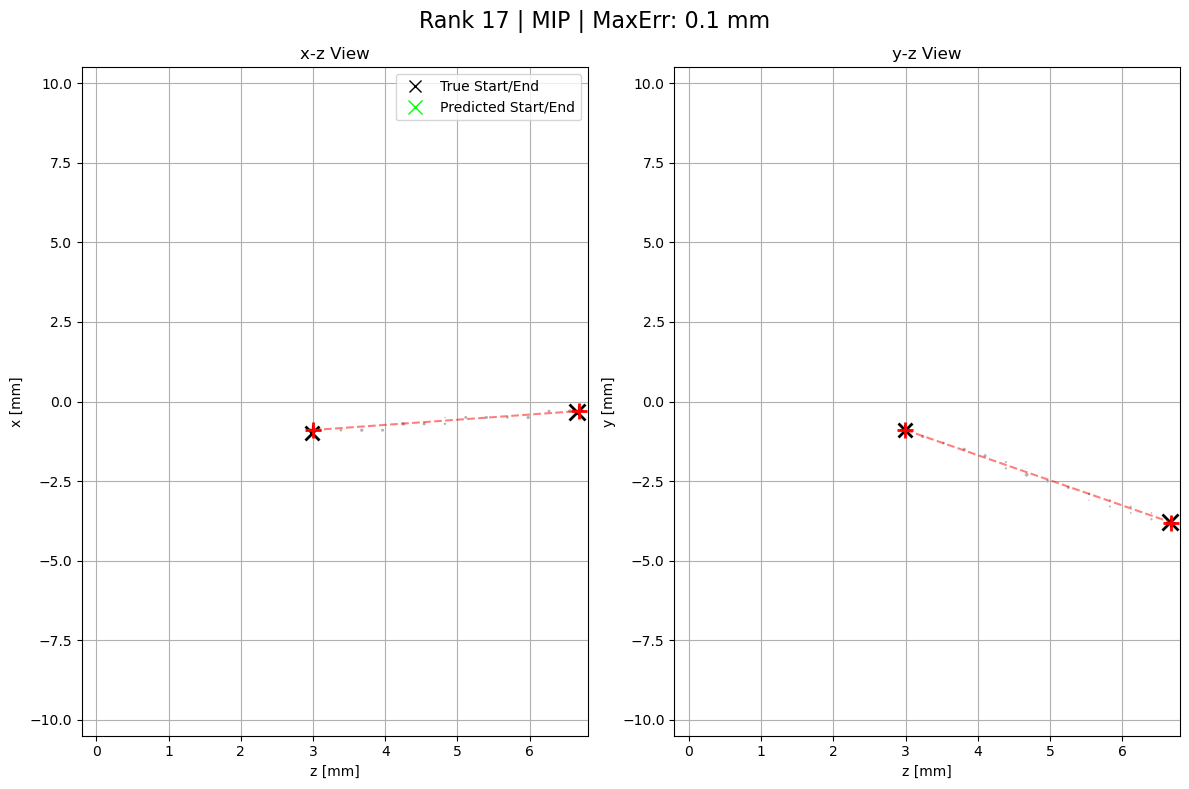

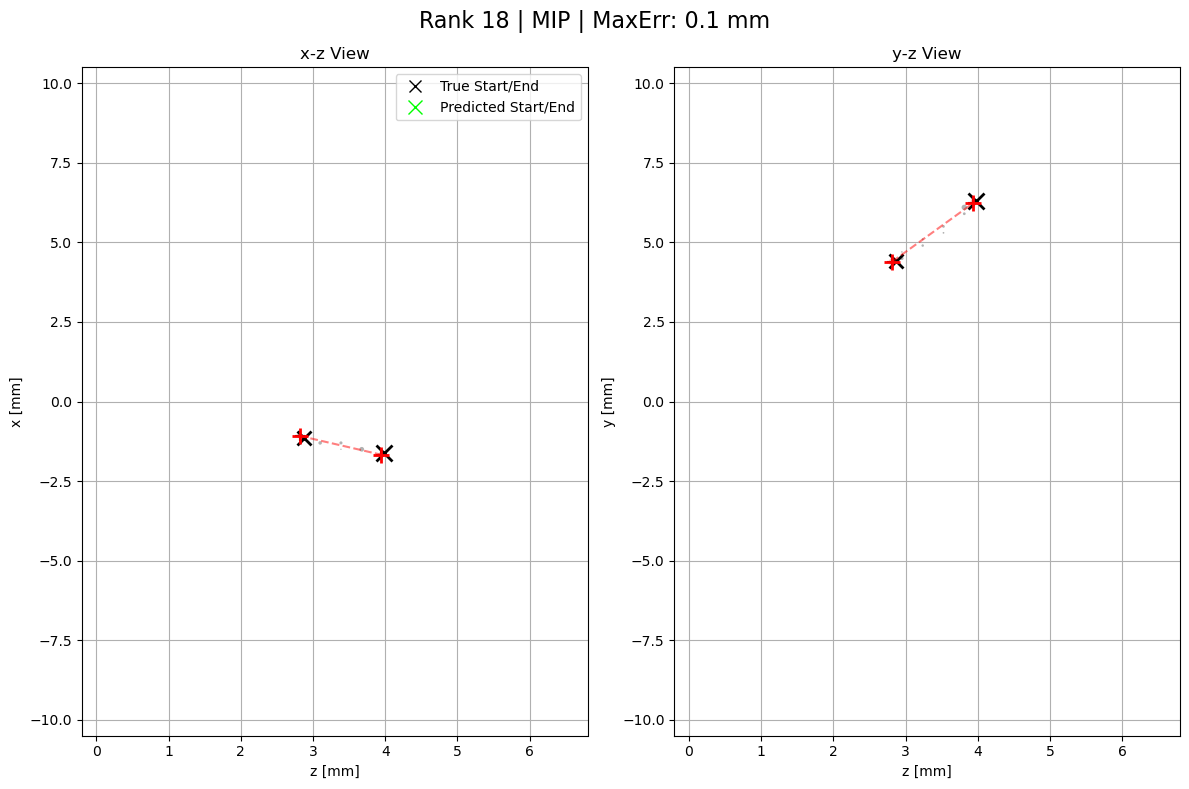

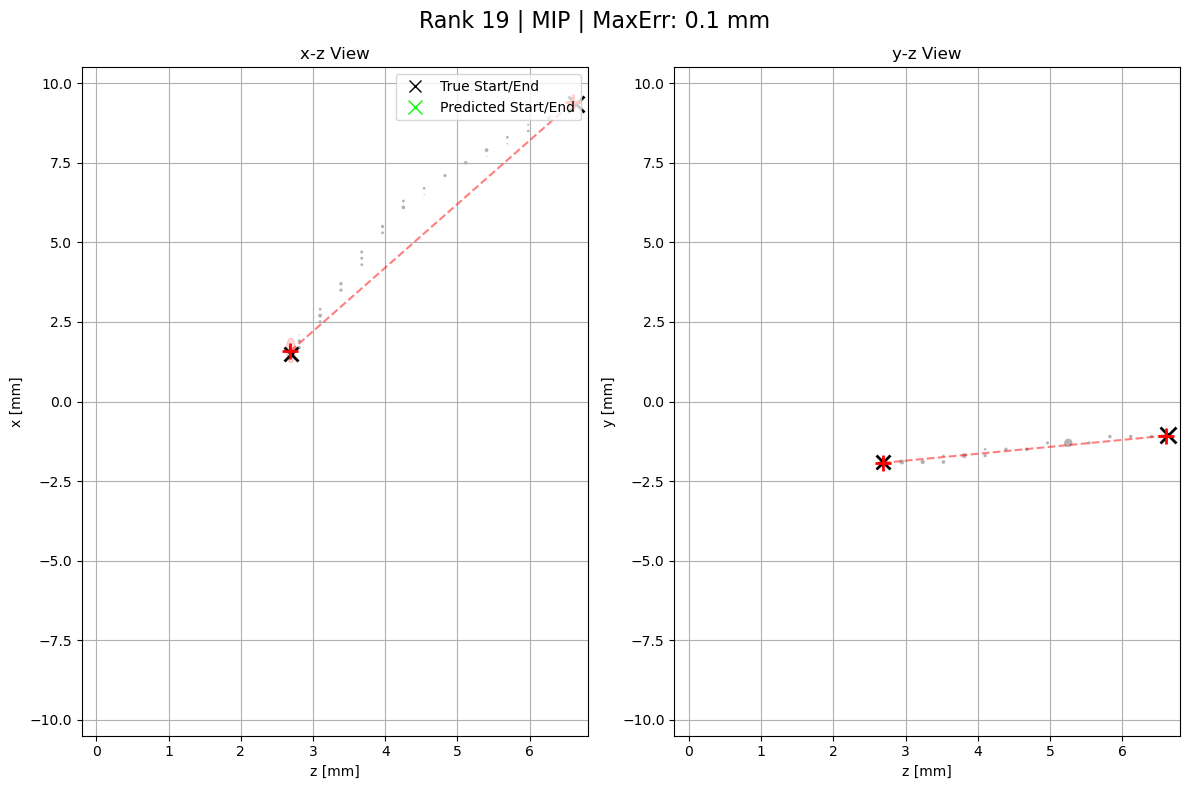

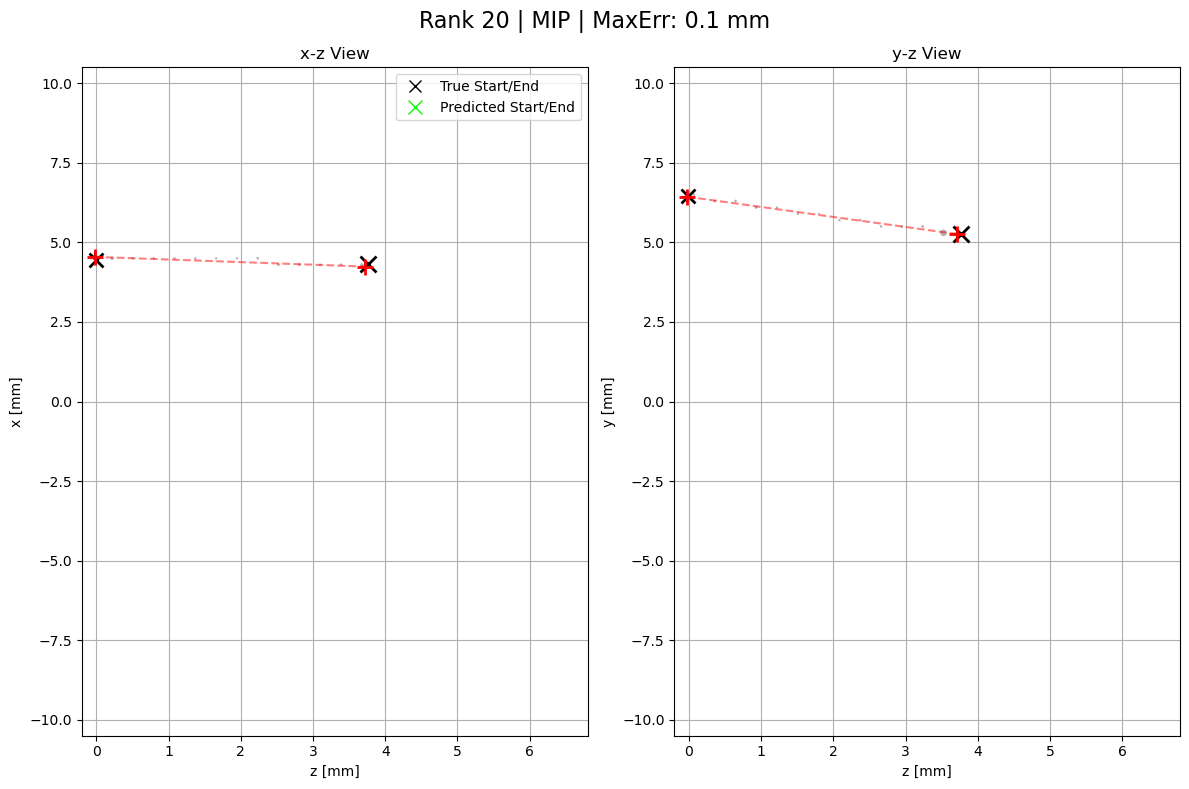

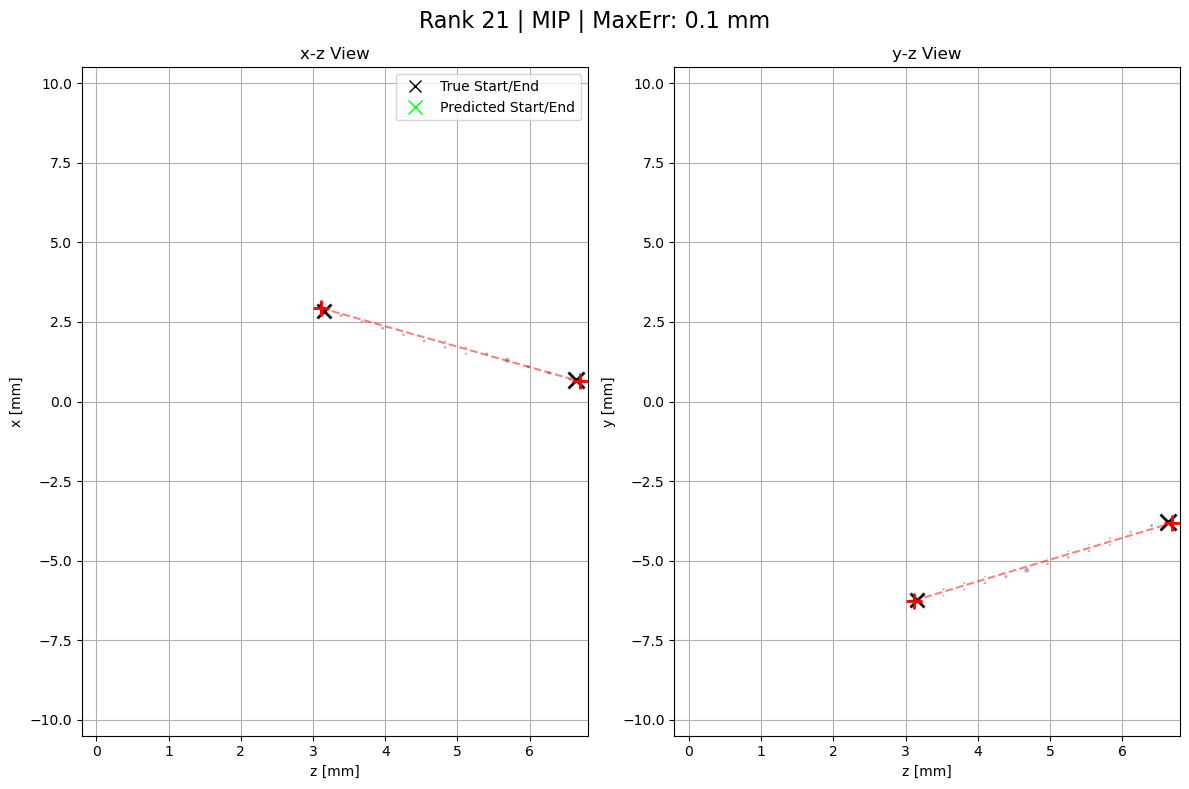

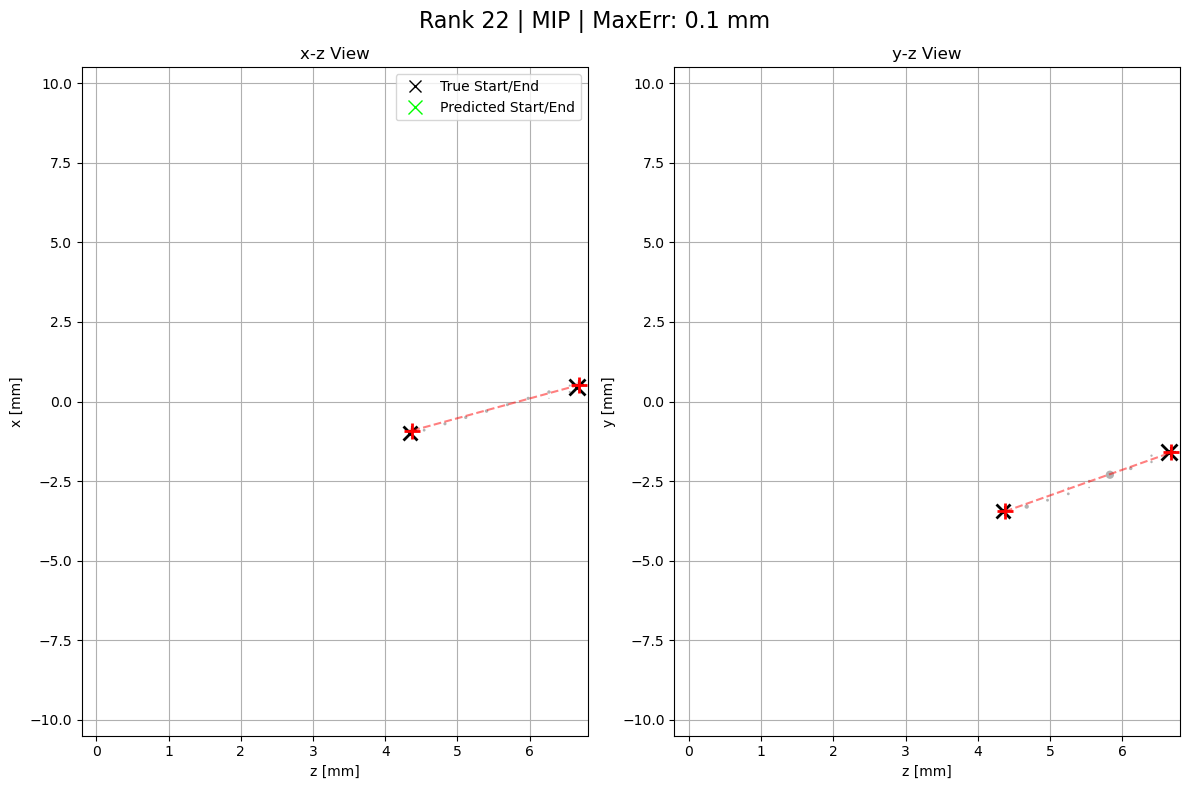

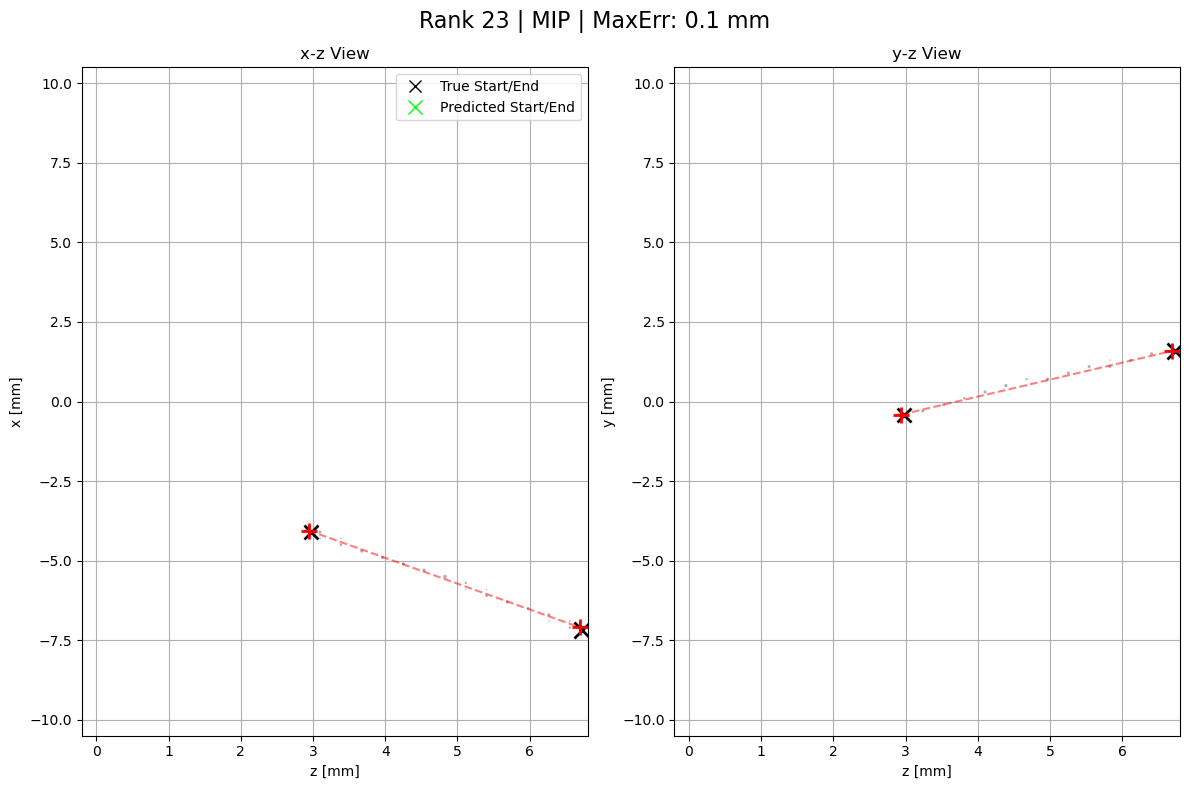

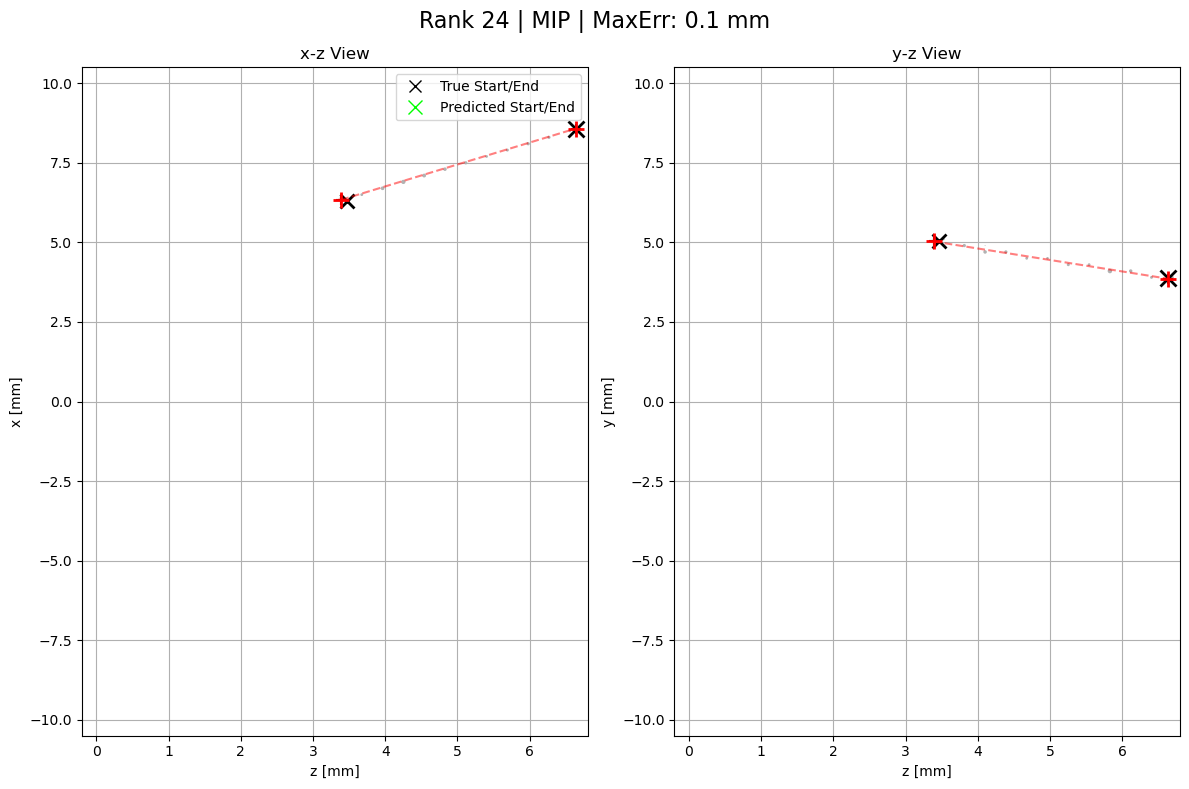

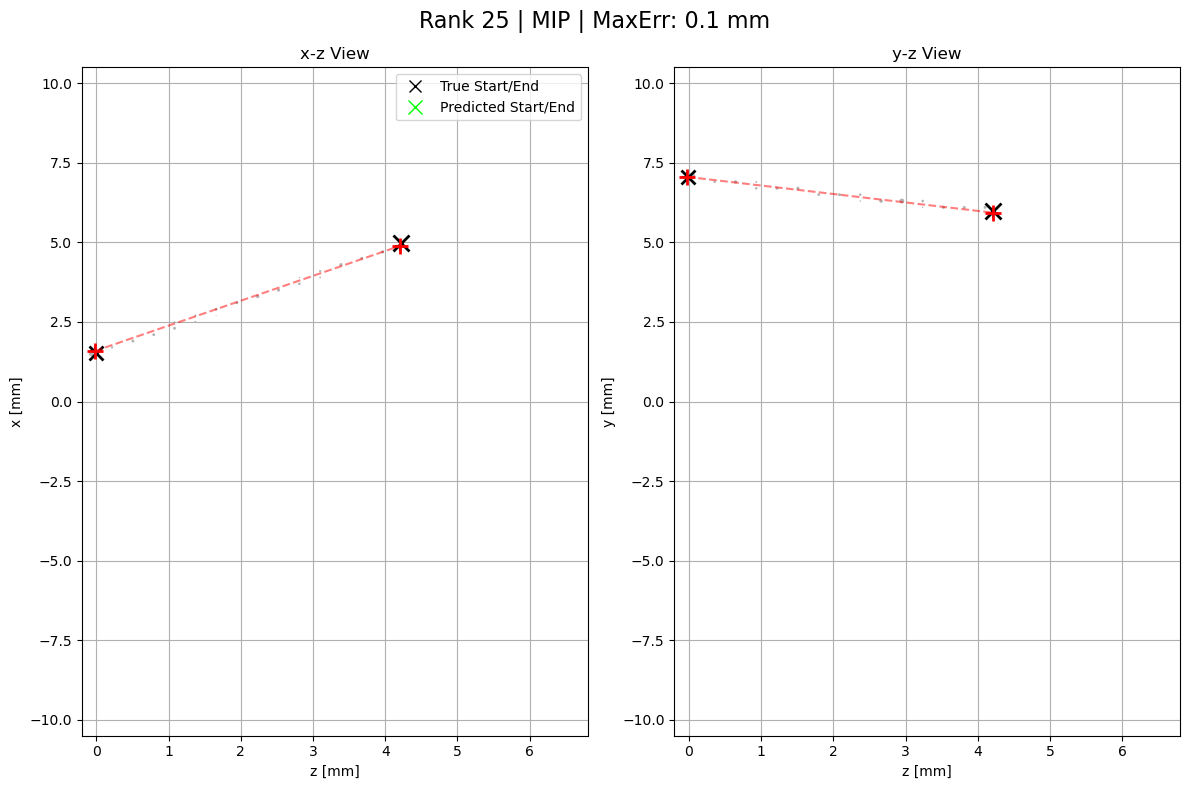

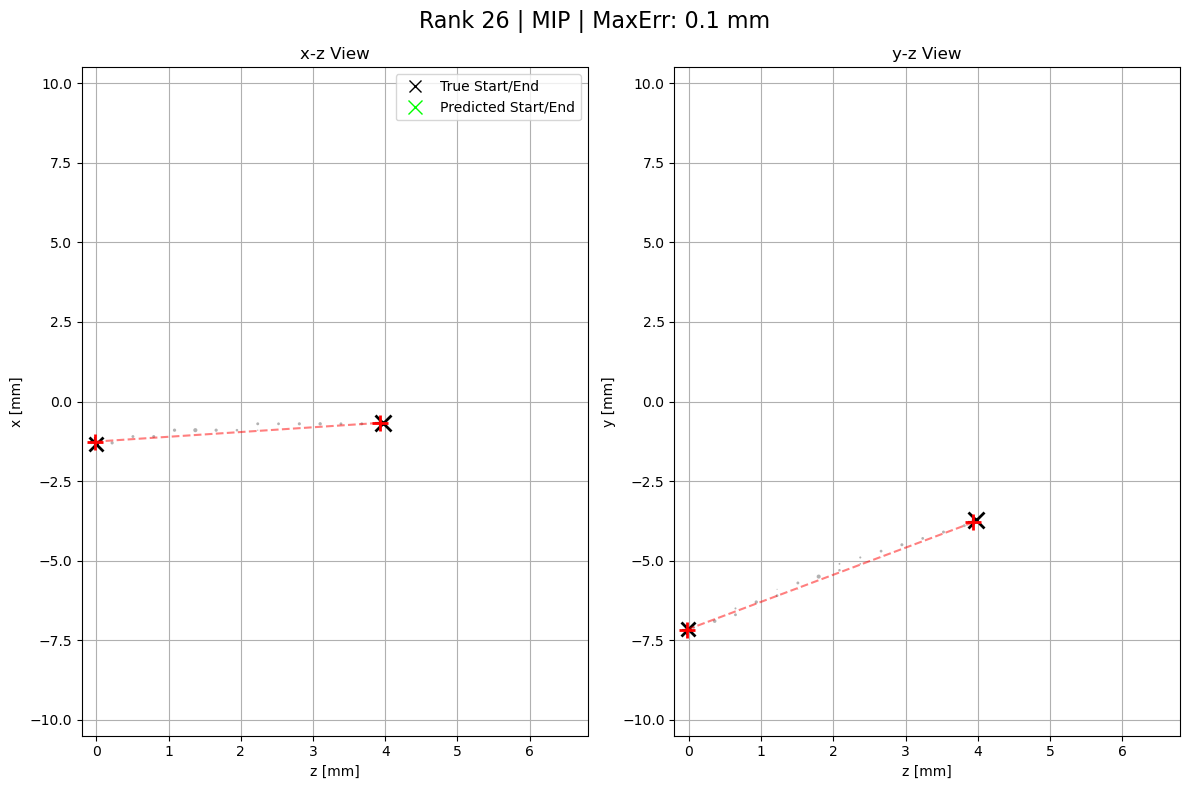

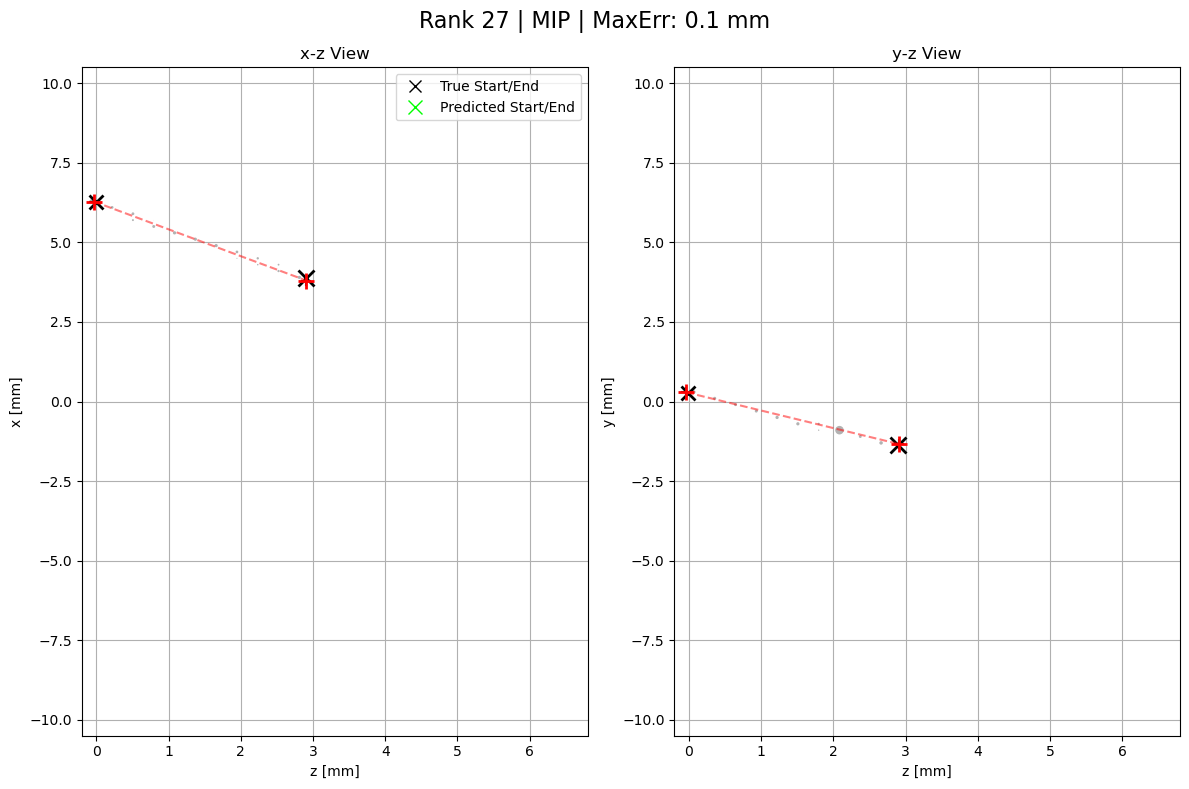

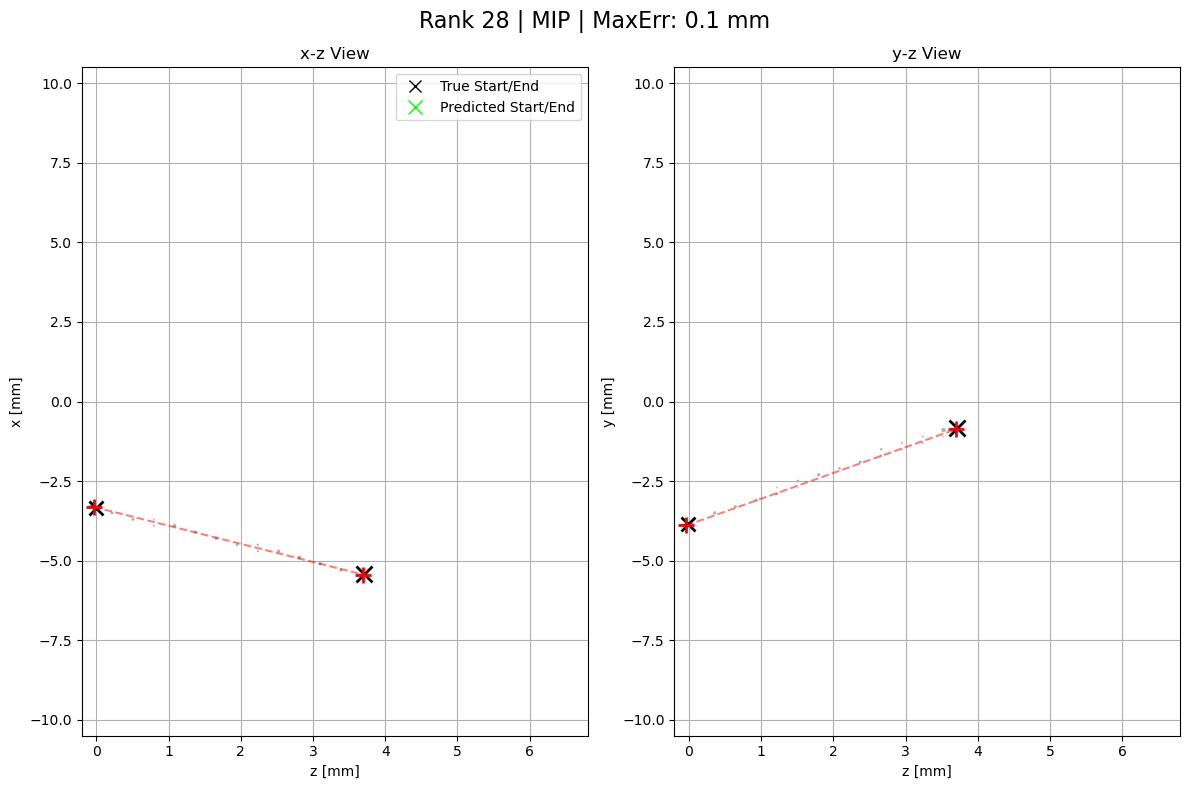

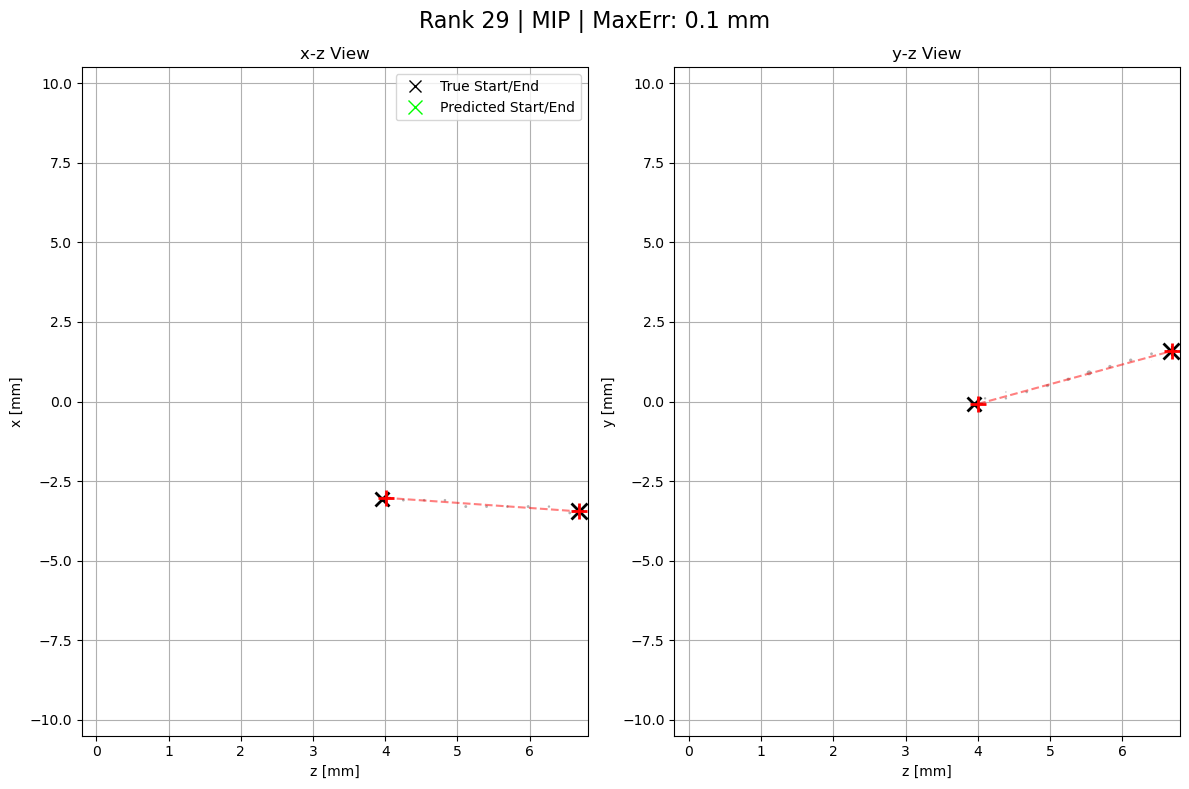

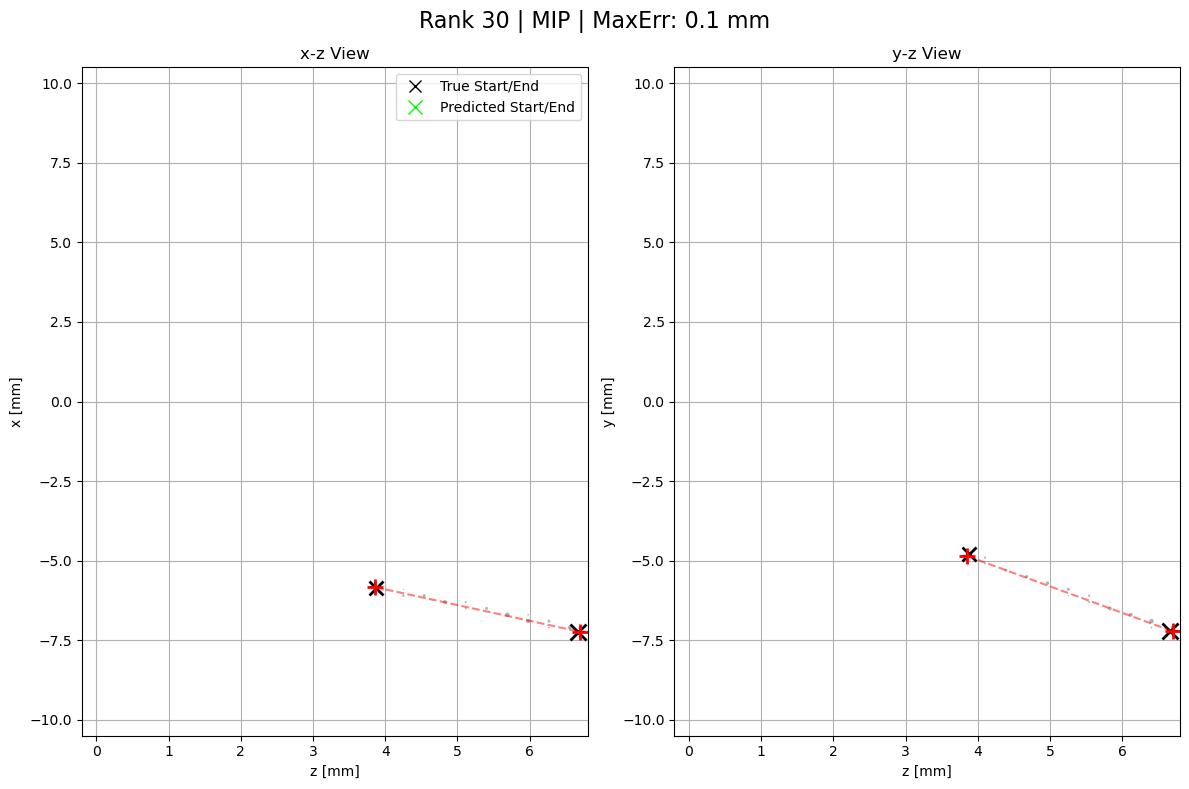

In [29]:
visualize_uncertainties_safe(test_loader, model, DEVICE, num_events=30, target_class=2)

In [27]:
torch.save(model.state_dict(), '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/endpoint_finder_12_25_2025.pth')